# Module 4B — Four real systems, from the printed table to the equation of state

**2105603 Advanced Chemical Engineering Thermodynamics**
Department of Chemical Engineering, Chulalongkorn University
Soorathep Kheawhom

---

Module 4 built the machinery on a dataset whose answer was known, because that
is the only way to test machinery. This notebook points the same machinery at
**five published datasets whose answer nobody knows**, covering the four
deviation classes the course uses. Every one carries its DOI in the cell that
loads it.

| step | question |
|---|---|
| 1 | what makes a mixture Type 1, 2, 3 or 4 — and can you predict it before looking? |
| 2 | where is the azeotrope, why is it a minimum or a maximum, and how does it move with pressure? |
| 3 | BUBL P, DEW P, BUBL T, DEW T — written from scratch, then checked |
| 4 | how much do the vapour-phase corrections actually move $\gamma$? |
| 5 | five consistency tests on real data, read as a diagnosis rather than a verdict |
| 6 | fitting a model when there is no true answer to compare against |
| 7 | five activity models with identical $\gamma^\infty$: what is left is the shape of $G^E$ |
| 8 | the same system through $\gamma$–$\varphi$, $\varphi$–$\varphi$, Huron–Vidal and Wong–Sandler |

Sections stand alone. Run Section 0 first, then any section you were assigned.

**Rule for this notebook, as for Modules 4 and 5.** Every number reported here
must be reproduced by an independent route, and every number came out of a
paper that is cited where it is used. Nothing below is quoted from memory.

**What is *not* here.** Regression machinery — objective functions, bootstrap,
cross-validation, UNIFAC benchmarking, the domain-of-validity statement — is
Module 4's subject and is not repeated. Sections 6 and 7 use it and point back
to it.

## 0. Setup

In [1]:
import sys, subprocess, importlib, os

def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        pipname or pkg], check=False)

for p in ("numpy", "scipy", "matplotlib"):
    ensure(p)

if not os.path.isdir("vlekit"):
    import urllib.request, zipfile, io
    URL = "https://www.skhgroup.net/teaching/2105603/files/vlekit.zip"
    try:
        with urllib.request.urlopen(URL, timeout=30) as r:
            zipfile.ZipFile(io.BytesIO(r.read())).extractall(".")
        print("downloaded vlekit from the course page")
    except Exception as e:
        print("could not download vlekit:", e)

import numpy as np
import matplotlib.pyplot as plt
import vlekit as v
from vlekit import datasets as DS, consistency as C, flash as F, plots as pl
from vlekit import cubic as CU, gemix as GX

pl.use_style()
print("vlekit", v.__version__)

vlekit 0.1.0


In [2]:
# The five sets, loaded once. TYPES carries the course's 1-4 classification and
# DOIS the source paper; both live beside the data in vlekit/datasets.py, where
# every verification check that was run on the numbers is also recorded.
NAMES = ["benzene-toluene", "methanol-water", "ethanol-water",
         "chloroform-butanone", "acetone-chloroform"]
SETS = {n: DS.load(n) for n in NAMES}

print(f"{'dataset':24s}{'type':>5}{'n':>4}  {'kind':10s}{'condition':>18}   DOI")
for n in NAMES:
    d = SETS[n]
    cond = (f"T = {d.T[0]:.2f} K" if d.kind == "isothermal"
            else f"P = {d.P[0]:.2f} kPa")
    print(f"{n:24s}{DS.TYPES[n]:>5}{d.n:>4}  {d.kind:10s}{cond:>18}   {DS.DOIS[n]}")

dataset                  type   n  kind               condition   DOI
benzene-toluene             1  13  isobaric      P = 101.33 kPa   10.1016/j.fluid.2013.12.002
methanol-water              2  16  isobaric       P = 66.52 kPa   10.1021/je300613v
ethanol-water               3  21  isobaric      P = 101.30 kPa   10.1021/je2008704
chloroform-butanone         4  22  isothermal      T = 303.15 K   10.1021/je060150a
acetone-chloroform          4   9  isobaric      P = 101.30 kPa   10.3390/app8091519


Read `vlekit/datasets.py` before using any of these. Beside every table it
records what was checked: that the DOI resolves, that the paper carries no
retraction or correction, how the numbers were transcribed, how far the
pure-component end points are from the Antoine correlations, and what the five
consistency tests said — failures included. Three of the five sets fail at
least one test. Section 5 is about reading those failures.

Two of the five are the *same* deviation class (chloroform + 2-butanone and
acetone + chloroform are both Type 4). That is deliberate: the first is the
better dataset and the only isothermal set here, the second is the textbook
example and the only one that is open access.

---

## 1. The four solution types, derived rather than asserted

The course classifies a binary by what $G^E$ does:

| type | $G^E$ | $\gamma$ | azeotrope |
|---|---|---|---|
| 1 | $\approx 0$ | $\approx 1$ | no |
| 2 | $> 0$ | $> 1$, but not by enough | no |
| 3 | $> 0$ | $> 1$ | yes, minimum-boiling |
| 4 | $< 0$ | $< 1$ | yes, maximum-boiling |

Notice that the azeotrope column is not a separate fact. It follows from the
first two, *together with the pure-component vapour pressures*, and the point
of this section is that you can work out which column a system belongs in
before you look at the middle of its data.

Start with $\gamma$ from the raw table under modified Raoult's law,
$\gamma_i = y_i P / (x_i P_i^{\rm sat})$. Section 4 asks what that assumption
costs; take it for now.

In [3]:
print(f"{'dataset':24s}{'gamma1 range':>22}{'gamma2 range':>22}")
for n in NAMES:
    d = SETS[n]
    g1, g2 = d.gamma("ideal")
    m = d.interior() & np.isfinite(g1) & np.isfinite(g2)
    print(f"{n:24s}{g1[m].min():>11.3f}{g1[m].max():>11.3f}"
          f"{g2[m].min():>11.3f}{g2[m].max():>11.3f}")

dataset                           gamma1 range          gamma2 range
benzene-toluene               0.990      1.003      0.934      1.014
methanol-water                1.007      2.166      1.008      1.371
ethanol-water                 0.997      5.303      0.999      2.543
chloroform-butanone           0.401      1.002      0.362      1.043
acetone-chloroform            0.531      1.000      0.574      0.994


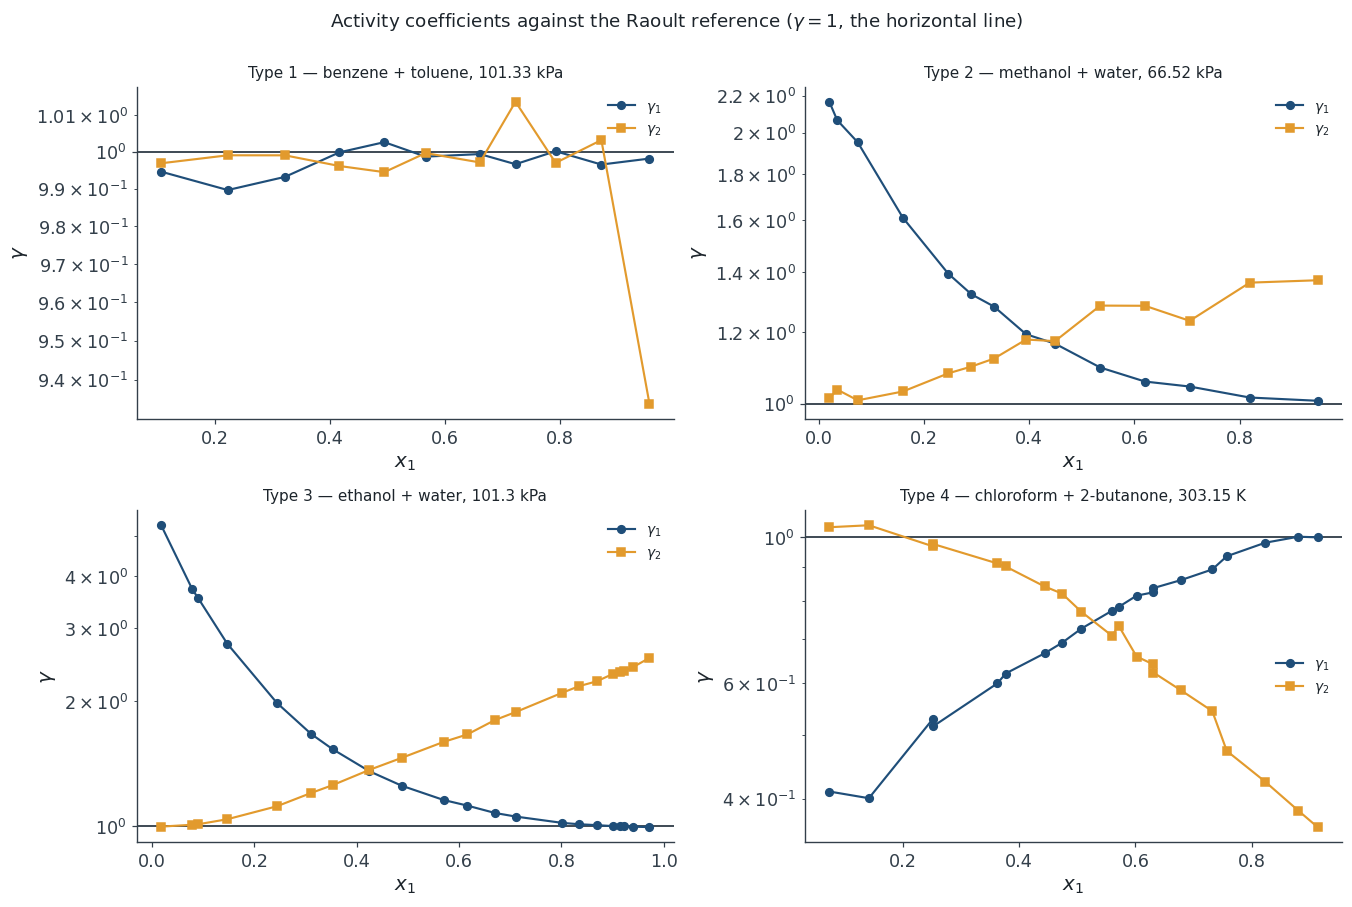

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.2))
for ax, n in zip(axes.ravel(), NAMES[:4]):
    d = SETS[n]
    g1, g2 = d.gamma("ideal")
    m = d.interior() & np.isfinite(g1) & np.isfinite(g2)
    ax.axhline(1.0, color=pl.GRAPHITE, lw=1.2)            # the Raoult reference
    ax.plot(d.x1[m], g1[m], "o-", color=pl.NAVY, ms=5, lw=1.4,
            label=r"$\gamma_1$")
    ax.plot(d.x1[m], g2[m], "s-", color=pl.AMBER, ms=5, lw=1.4,
            label=r"$\gamma_2$")
    ax.set_yscale("log")
    ax.set_xlabel("$x_1$"); ax.set_ylabel(r"$\gamma$")
    ax.set_title(f"Type {DS.TYPES[n]} — {d.label}", fontsize=10)
    ax.legend(loc="best", fontsize=9)
fig.suptitle("Activity coefficients against the Raoult reference "
             r"($\gamma = 1$, the horizontal line)", y=1.00)
plt.tight_layout(); plt.show()

### 1.1 The azeotrope condition, and what it reduces to at the ends

An azeotrope is $y_1 = x_1$. Under modified Raoult's law
$y_1 P = x_1\gamma_1 P_1^{\rm sat}$ and $y_2 P = x_2\gamma_2 P_2^{\rm sat}$, so
dividing,

$$\frac{y_1/x_1}{y_2/x_2} \;=\; \alpha_{12} \;=\;
  \frac{\gamma_1 P_1^{\rm sat}}{\gamma_2 P_2^{\rm sat}}$$

and $y_1 = x_1$ is exactly $\alpha_{12} = 1$, i.e.

$$\frac{\gamma_1}{\gamma_2} \;=\; \frac{P_2^{\rm sat}}{P_1^{\rm sat}}$$

**An azeotrope exists if and only if that equation has a root in $(0,1)$.**
$\gamma_1/\gamma_2$ is continuous and its two end values are known without any
data from the middle of the range: as $x_1 \to 0$ it is $\gamma_1^\infty$
(because $\gamma_2 \to 1$), and as $x_1 \to 1$ it is $1/\gamma_2^\infty$. So

$$\alpha_{12}(x_1 \to 0) = \gamma_1^\infty \frac{P_1^{\rm sat}}{P_2^{\rm sat}},
\qquad
\alpha_{12}(x_1 \to 1) = \frac{1}{\gamma_2^\infty}
                          \frac{P_1^{\rm sat}}{P_2^{\rm sat}}$$

and if those two straddle 1, there is a root between them. **Two infinite-dilution
activity coefficients and two vapour pressures decide the question.**

That is the prediction. Make it before running the check.

In [5]:
def gamma_infinity(d, order=3):
    """gamma_1^inf and gamma_2^inf by Redlich-Kister extrapolation of ln gamma.

    Fit ln gamma_1 and ln gamma_2 separately as polynomials in z = 2x1 - 1 and
    read them off at the ends. The data never reach the ends, so this IS an
    extrapolation and it is the weakest number in the section; Section 5 shows
    the Kojima test complaining about exactly this quantity.
    """
    d = d.sorted_by_x()
    g1, g2 = d.gamma("ideal")
    m = d.interior() & np.isfinite(g1) & np.isfinite(g2) & (g1 > 0) & (g2 > 0)
    c1 = C.rk_fit(d.x1[m], np.log(g1[m]), order)
    c2 = C.rk_fit(d.x1[m], np.log(g2[m]), order)
    return float(np.exp(C.rk_eval(c1, 0.0))), float(np.exp(C.rk_eval(c2, 1.0)))


def predict_type(d):
    """alpha_12 at both dilute limits, from gamma^inf and the vapour pressures."""
    g1inf, g2inf = gamma_infinity(d)
    T0 = float(d.T[np.argmin(d.x1)])          # T at the x1 -> 0 end of the set
    T1 = float(d.T[np.argmax(d.x1)])          # T at the x1 -> 1 end
    r0 = float(d.c1.Psat(T0) / d.c2.Psat(T0))
    r1 = float(d.c1.Psat(T1) / d.c2.Psat(T1))
    return g1inf, g2inf, r0, r1, g1inf * r0, r1 / g2inf


print(f"{'dataset':24s}{'g1_inf':>8}{'g2_inf':>8}{'Ps1/Ps2 at the ends':>21}"
      f"{'a(x1->0)':>10}{'a(x1->1)':>10}   predicted")
for n in NAMES:
    g1i, g2i, r0, r1, a0, a1 = predict_type(SETS[n])
    azeo = (a0 - 1) * (a1 - 1) < 0
    if azeo:
        kind = "azeotrope, min-boiling" if g1i > 1 else "azeotrope, max-boiling"
    else:
        kind = "no azeotrope, near-ideal" if abs(np.log(g1i)) < 0.1 \
            else "no azeotrope, positive dev."
    print(f"{n:24s}{g1i:>8.3f}{g2i:>8.3f}{r0:>11.3f}{r1:>10.3f}"
          f"{a0:>10.3f}{a1:>10.3f}   {kind}")

dataset                   g1_inf  g2_inf  Ps1/Ps2 at the ends  a(x1->0)  a(x1->1)   predicted
benzene-toluene            0.991   0.927      2.351     2.608     2.330     2.815   no azeotrope, near-ideal
methanol-water             2.281   1.360      3.644     4.337     8.314     3.190   no azeotrope, positive dev.
ethanol-water              5.713   2.566      2.257     2.298    12.891     0.896   azeotrope, min-boiling
chloroform-butanone        0.353   0.288      2.124     2.124     0.750     7.386   azeotrope, max-boiling
acetone-chloroform         0.445   0.497      1.183     1.181     0.527     2.379   azeotrope, max-boiling


### 1.2 The check

The prediction used only the two extrapolated end values and the Antoine
correlations. The check uses the measured $x_1$ and $y_1$ in the middle of the
range and nothing else:

$$\alpha_{12} = \frac{y_1/x_1}{(1-y_1)/(1-x_1)}$$

These two routes share no numbers at all — the prediction never touches $y_1$
except through the extrapolated end points, and the check never touches
$P^{\rm sat}$.

In [6]:
print(f"{'dataset':24s}{'alpha from data':>26}{'crosses 1':>11}   "
      f"{'predicted':>10}   agree?")
for n in NAMES:
    d = SETS[n].sorted_by_x()
    m = d.interior()
    al = (d.y1[m] / d.x1[m]) * ((1 - d.x1[m]) / (1 - d.y1[m]))
    seen = al.min() < 1.0 < al.max()
    _, _, _, _, a0, a1 = predict_type(SETS[n])
    pred = (a0 - 1) * (a1 - 1) < 0
    print(f"{n:24s}{al.min():>13.3f}{al.max():>13.3f}{str(seen):>11}   "
          f"{str(pred):>10}   {'yes' if seen == pred else 'NO'}")

dataset                            alpha from data  crosses 1    predicted   agree?
benzene-toluene                 2.380        2.778      False        False   yes
methanol-water                  3.172        7.911      False        False   yes
ethanol-water                   0.900       11.976       True         True   yes
chloroform-butanone             0.816        5.860       True         True   yes
acetone-chloroform              0.632        2.059       True         True   yes


Five for five, and the numbers line up more closely than the verdict alone
shows. For ethanol + water the prediction from $\gamma^\infty$ and the vapour
pressures was $\alpha = 12.89$ at the dilute-ethanol end and $0.896$ at the
dilute-water end; the measured relative volatilities run from $11.98$ down to
$0.900$. The extrapolation and the measurement agree at the end where the
data reach furthest ($x_1 = 0.972$) and disagree by 8 % at the end where they
stop at $x_1 = 0.018$, which is the right way round.

So the classification is now derived:

- **benzene + toluene, Type 1.** $\gamma_1^\infty = 0.991$ and
  $\gamma_2^\infty = 0.927$ — both within about 7 % of unity. Two aromatics
  differing by one methyl group: the unlike interaction is close to the mean of
  the like ones, so $G^E \approx 0$. With $\alpha$ never near 1 there is no
  azeotrope and no chance of one.
- **methanol + water, Type 2.** $\gamma_1^\infty = 2.28$, genuinely positive
  deviation — but $P^{\rm sat}_{\rm MeOH}/P^{\rm sat}_{\rm H_2O}$ is already
  3.6–4.3, so $\alpha$ stays above 3 across the whole range. **The deviation is
  real and the azeotrope is absent, and the reason is the vapour-pressure ratio,
  not the deviation.** This is the distinction between Types 2 and 3, and it is
  a statement about both components together.
- **ethanol + water, Type 3.** The same hydrogen-bonding argument as methanol,
  but the ethyl group makes the mismatch far larger: $\gamma_1^\infty = 5.71$.
  Now $\gamma_1^\infty$ beats the vapour-pressure ratio at one end and
  $1/\gamma_2^\infty$ loses to it at the other, so $\alpha$ must cross 1.
- **chloroform + 2-butanone and acetone + chloroform, Type 4.** The acidic C–H
  of chloroform hydrogen-bonds to the carbonyl, an interaction neither pure
  liquid has. Mixing is favourable, $\gamma < 1$ throughout
  ($\gamma_1^\infty = 0.353$ and $0.445$), and $\alpha$ crosses 1 from below.

**Question 1.1.** Methanol + water has $\gamma_1^\infty = 2.28$. Holding that
fixed, how small would $P^{\rm sat}_1/P^{\rm sat}_2$ have to become before an
azeotrope appeared? Is that a pressure you could reach, and what does your
answer say about pressure-swing separation of methanol and water?

**Question 1.2.** $\gamma_1^\infty$ above came from extrapolating a cubic in
$2x_1 - 1$ to $x_1 = 0$. For ethanol + water the nearest measured point is
$x_1 = 0.018$; for acetone + chloroform it is $x_1 = 0.102$. Refit with
`order=2` and `order=4` and report how much $\gamma_1^\infty$ moves in each
case. Which of the five predictions above would you be prepared to defend?

---

## 2. Minimum- and maximum-boiling azeotropes

### 2.1 Locating them in the table

No model, no fit: find where $y_1 - x_1$ changes sign between two measured rows
and interpolate. The pure end points are excluded, because $y_1 = x_1$ there is
trivially true and is not an azeotrope.

In [7]:
def azeotrope_from_table(d):
    """Every interior sign change of y1 - x1, linearly interpolated."""
    d = d.sorted_by_x()
    f = d.y1 - d.x1
    out = []
    for i in range(d.n - 1):
        if d.x1[i] < 1e-9 or d.x1[i + 1] > 1 - 1e-9:
            continue                      # skip the pure end points
        if f[i] * f[i + 1] < 0:
            t = f[i] / (f[i] - f[i + 1])
            out.append({"x1": d.x1[i] + t * (d.x1[i + 1] - d.x1[i]),
                        "T": d.T[i] + t * (d.T[i + 1] - d.T[i]),
                        "P": d.P[i] + t * (d.P[i + 1] - d.P[i])})
    return out

for n in NAMES:
    d = SETS[n]
    az = azeotrope_from_table(d)
    if not az:
        print(f"{n:24s} no interior azeotrope")
    for a in az:
        print(f"{n:24s} x_az = {a['x1']:.4f}   T = {a['T']:.2f} K   "
              f"P = {a['P']:.2f} kPa")

benzene-toluene          no interior azeotrope
methanol-water           no interior azeotrope
ethanol-water            x_az = 0.8946   T = 351.26 K   P = 101.30 kPa
chloroform-butanone      x_az = 0.1907   T = 303.15 K   P = 15.42 kPa
acetone-chloroform       x_az = 0.3777   T = 337.60 K   P = 101.30 kPa


Against what the papers say:

| system | this table | the paper | source |
|---|---|---|---|
| ethanol + water, 101.3 kPa | $x_{\rm az} = 0.8946$, 351.26 K | 0.894 (accepted literature value at this pressure) | [10.1021/je2008704](https://doi.org/10.1021/je2008704) |
| chloroform + 2-butanone, 303.15 K | $x_{\rm az} = 0.1907$, $P = 15.42$ kPa | "a minimum pressure azeotrope at $x_1 = 0.199$ and $p = 15.3$ kPa" | [10.1021/je060150a](https://doi.org/10.1021/je060150a) |
| acetone + chloroform, 101.3 kPa | $x_{\rm az} = 0.3777$, 337.6 K | 64.5 °C at roughly $x_1 = 0.34$–$0.36$ | [10.3390/app8091519](https://doi.org/10.3390/app8091519) |

The chloroform + 2-butanone agreement is the most informative of the three,
because it tests the $x$, $y$ and $P$ columns *jointly* against a number the
authors computed independently: the pressure matches to 0.1 kPa and the
composition to 0.008. The acetone + chloroform composition is high by about
0.03, which is what a nine-point grid across a flat maximum will give — the
measured temperature is 337.6 K at both $x_1 = 0.301$ and $x_1 = 0.396$, so the
table simply cannot resolve the maximum better than that. Its **temperature**,
64.45 °C, matches the accepted 64.5 °C to 0.05 K.

The lowest measured pressure in the chloroform + 2-butanone table is 15.33 kPa,
against the interpolated azeotropic 15.42 kPa. The interpolant does not have to
pass through the lowest measured point, and it does not.

### 2.2 Why positive deviation gives a *minimum*-boiling azeotrope

The Gibbs–Konovalov theorem: at constant $T$, $\mathrm{d}P/\mathrm{d}x_1 = 0$
exactly where $y_1 = x_1$. So an azeotrope is always a stationary point of the
$P$–$x$ curve, and the only question is which kind.

Positive deviation means $\gamma_i > 1$, so
$P = x_1\gamma_1 P_1^{\rm sat} + x_2\gamma_2 P_2^{\rm sat}$ lies **above** the
Raoult straight line joining $P_2^{\rm sat}$ to $P_1^{\rm sat}$, at every
composition. A continuous curve that starts and ends on a straight line and lies
above it everywhere in between has an interior **maximum**. A maximum in $P$ at
fixed $T$ is a **minimum in $T$ at fixed $P$** — the mixture boils below both
pure components. Negative deviation reverses every step.

The argument is complete without any model. Check it anyway, because the check
is one line.

In [8]:
def konovalov_check(d, model, T):
    """dP/dx1 at the azeotrope, and where P is stationary, from the model."""
    az = F.azeotrope(model, T, d.c1, d.c2)
    if az is None:
        return None
    h = 1e-5
    Pp, _ = v.bubble_P(model, np.array([az["x1"] + h]), np.array([T]), d.c1, d.c2)
    Pm, _ = v.bubble_P(model, np.array([az["x1"] - h]), np.array([T]), d.c1, d.c2)
    az["dPdx"] = float((Pp[0] - Pm[0]) / (2 * h))
    return az

for n in ("ethanol-water", "chloroform-butanone", "acetone-chloroform"):
    d = SETS[n]
    # evaluate at the temperature the measured azeotrope actually sits at, so
    # the model and the table in 2.1 are comparable
    T = float(azeotrope_from_table(d)[0]["T"])
    tab = azeotrope_from_table(d)[0]["x1"]
    az = konovalov_check(d, v.fit(d, "nrtl").model, T)
    print(f"{n:24s} at T = {T:.2f} K: x_az = {az['x1']:.4f}, "
          f"P = {az['P']:.2f} kPa, {az['kind']}")
    print(f"{'':24s}   dP/dx1 there = {az['dPdx']:+.2e} kPa "
          f"(Gibbs-Konovalov says zero)")
    print(f"{'':24s}   the table said x_az = {tab:.4f}, "
          f"so the fitted model is off by {az['x1'] - tab:+.4f}")

ethanol-water            at T = 351.26 K: x_az = 0.9172, P = 101.32 kPa, maximum-pressure
                           dP/dx1 there = -2.13e-09 kPa (Gibbs-Konovalov says zero)
                           the table said x_az = 0.8946, so the fitted model is off by +0.0226
chloroform-butanone      at T = 303.15 K: x_az = 0.1410, P = 14.99 kPa, minimum-pressure
                           dP/dx1 there = +1.95e-09 kPa (Gibbs-Konovalov says zero)
                           the table said x_az = 0.1907, so the fitted model is off by -0.0497


acetone-chloroform       at T = 337.60 K: x_az = 0.3395, P = 101.23 kPa, minimum-pressure
                           dP/dx1 there = -1.42e-09 kPa (Gibbs-Konovalov says zero)
                           the table said x_az = 0.3777, so the fitted model is off by -0.0382


$\mathrm{d}P/\mathrm{d}x_1$ is zero at the azeotrope to nine decimal places in
all three systems, which is Gibbs–Konovalov confirmed rather than quoted.

The last line of each block is the uncomfortable one. **The fitted model
misplaces the azeotrope**, even though the same fits reproduce the measured
pressures or temperatures to well within the scatter (Section 6: rms
$\mathrm{d}P = 0.32$ kPa on 22 points spanning 15–32 kPa). There is no
contradiction. The azeotrope sits exactly where the $P$–$x$ curve is *flat*, so
the pressure carries almost no information about its location, and a
two-parameter model trading a little error there for a better fit elsewhere
pays almost nothing in the objective function. **If the azeotropic composition
is the number your design depends on, it must be in the objective function.**
Reading it off a model fitted to $P$–$x$ is reading a quantity the fit was
indifferent to.

The figure below uses the same fits and inherits the same caveat: the star is
where the *model* puts the azeotrope, not where the table does.

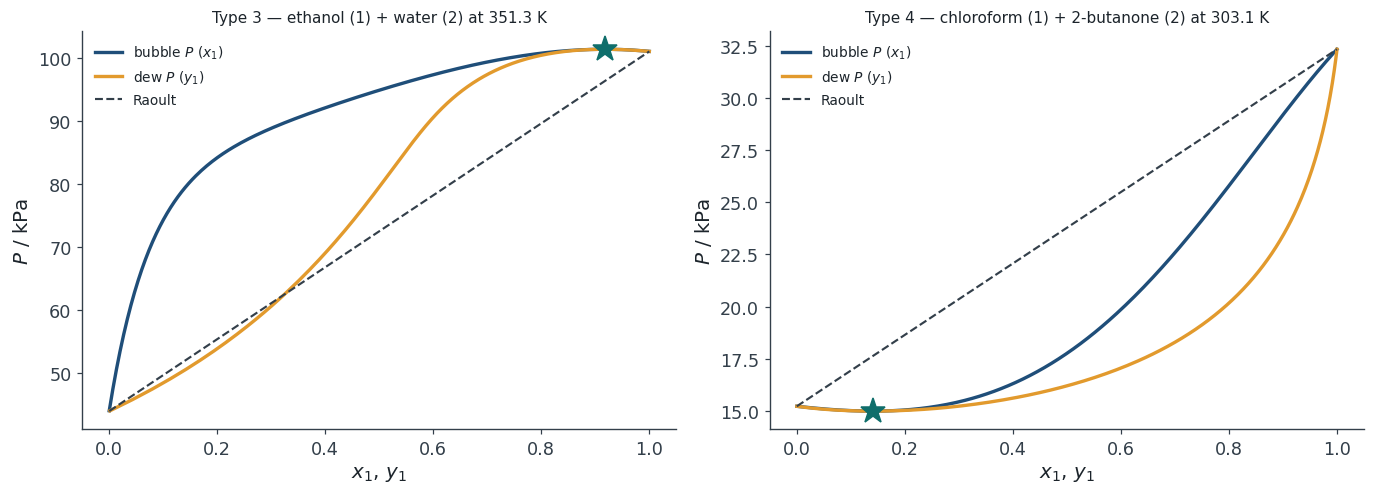

In [9]:
# The picture: P-x-y at fixed T for a Type 3 and a Type 4 system, against the
# Raoult straight line. NRTL fitted to each set; the assumption that tau does
# not vary with T is discussed in 2.3.
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for ax, n in zip(axes, ("ethanol-water", "chloroform-butanone")):
    d = SETS[n]
    T = float(azeotrope_from_table(d)[0]["T"])
    m = v.fit(d, "nrtl").model
    xs = np.linspace(1e-4, 1 - 1e-4, 300)
    P, y = v.bubble_P(m, xs, np.full_like(xs, T), d.c1, d.c2)
    Ps1, Ps2 = float(d.c1.Psat(T)), float(d.c2.Psat(T))
    ax.plot(xs, P, "-", color=pl.NAVY, lw=2.2, label="bubble $P$ ($x_1$)")
    ax.plot(y, P, "-", color=pl.AMBER, lw=2.2, label="dew $P$ ($y_1$)")
    ax.plot([0, 1], [Ps2, Ps1], "--", color=pl.GRAPHITE, lw=1.4,
            label="Raoult")
    az = F.azeotrope(m, T, d.c1, d.c2)
    ax.plot([az["x1"]], [az["P"]], "*", color=pl.TEAL, ms=17, zorder=5)
    ax.set_xlabel("$x_1$, $y_1$"); ax.set_ylabel("$P$ / kPa")
    ax.set_title(f"Type {DS.TYPES[n]} — {d.c1.name} (1) + {d.c2.name} (2) "
                 f"at {T:.1f} K", fontsize=10)
    ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

Left: the curve is above the Raoult line everywhere and has an interior
**maximum** in $P$ — positive deviation, minimum-boiling. Right: below the line
everywhere with an interior **minimum** in $P$ — negative deviation,
maximum-boiling. Note also that the bubble and dew curves *touch* at the star.
They must: $y_1 = x_1$ there.

### 2.3 Moving the pressure, and moving the azeotrope

An azeotropic composition is not a property of the mixture alone. It is set by
the balance between $\gamma_1/\gamma_2$, which depends mainly on composition,
and $P_2^{\rm sat}/P_1^{\rm sat}$, which depends only on temperature. Change the
temperature and the balance point moves. That is the entire basis of
pressure-swing distillation: run two columns at two pressures, and the
azeotrope that blocks one does not block the other.

**Assumption, stated because everything below depends on it.** NRTL is fitted
here to the 101.3 kPa isobaric data with $\tau_{12}, \tau_{21}$ held
*independent of temperature*. Extrapolating that fit down to 296 K is exactly
the kind of extrapolation Module 4 §9 is about: the data cannot check it. A
genuine design calculation needs $\tau_{ij}(T)$ fitted to data at more than one
pressure.

In [10]:
d = SETS["ethanol-water"]
mod = v.fit(d, "nrtl").model
print(f"NRTL fitted to {d.label}: "
      f"tau12 = {mod.params[0]:+.4f}, tau21 = {mod.params[1]:+.4f}\n")
print(f"{'T / K':>8}{'P_az / kPa':>13}{'x_az':>9}")
for T in (351.4, 340.0, 330.0, 320.0, 310.0, 300.0, 296.0, 294.0):
    az = F.azeotrope(mod, T, d.c1, d.c2)
    if az is None:
        print(f"{T:>8.1f}{'':>13}{'none — the azeotrope has gone':>9}")
    else:
        print(f"{T:>8.1f}{az['P']:>13.2f}{az['x1']:>9.4f}")

NRTL fitted to ethanol + water, 101.3 kPa: tau12 = -0.1712, tau21 = +1.9330

   T / K   P_az / kPa     x_az
   351.4       101.88   0.9170
   340.0        63.61   0.9304
   330.0        40.82   0.9434
   320.0        25.37   0.9578
   310.0        15.22   0.9738
   300.0         8.78   0.9917
   296.0         6.96   0.9994
   294.0             none — the azeotrope has gone


Two things to take from that table.

At 101.9 kPa the fitted model puts the azeotrope at $x_1 = 0.917$, against the
$0.8946$ read straight off the measured table in §2.1. **The model is 0.023
high**, and it is worth being clear why: NRTL was fitted by Barker's method to
$T$–$x$ over the whole range, not to the azeotrope, and 0.023 in $x_1$ near
$x_1 = 0.9$ is well within what a two-parameter model gives up elsewhere to fit
the rest of the curve. If the azeotrope is the number you need, fit for it.

Between 102 and 15 kPa the azeotrope moves from $x_1 = 0.917$ to $0.974$, and
below about 7 kPa the model says it disappears entirely. A separation using
those two pressures could in principle cross the composition the atmospheric
column cannot. In practice the ethanol + water swing is regarded as marginal —
0.057 in $x_1$ is a small prize for a second column and a vacuum system, which
is why industry uses extractive or azeotropic distillation instead.

Now the contrast that makes the point:

In [11]:
d2 = SETS["acetone-chloroform"]
mod2 = v.fit(d2, "nrtl").model
print(f"NRTL fitted to {d2.label}: "
      f"tau12 = {mod2.params[0]:+.4f}, tau21 = {mod2.params[1]:+.4f}\n")
print(f"{'T / K':>8}{'P_az / kPa':>13}{'x_az':>9}")
for T in (334.0, 330.0, 320.0, 310.0, 300.0):
    az = F.azeotrope(mod2, T, d2.c1, d2.c2)
    print(f"{T:>8.1f}{az['P']:>13.2f}{az['x1']:>9.4f}")

NRTL fitted to acetone + chloroform, 101.3 kPa: tau12 = -0.9621, tau21 = +0.4469

   T / K   P_az / kPa     x_az
   334.0        90.08   0.3402
   330.0        78.85   0.3409
   320.0        55.57   0.3429
   310.0        38.14   0.3449
   300.0        25.41   0.3469


Acetone + chloroform moves $x_{\rm az}$ from $0.3402$ to $0.3469$ — **0.007
over a factor of 3.5 in pressure**, against ethanol + water's 0.057. A pressure
swing on this pair is not a separation, it is a rounding error.

The reason is in Section 1's algebra. The azeotrope sits where
$\gamma_1/\gamma_2 = P_2^{\rm sat}/P_1^{\rm sat}$. For acetone + chloroform the
vapour-pressure ratio is near 1.18 and barely moves with temperature, and
$\gamma_1/\gamma_2$ is steep in composition, so the root hardly shifts. For
ethanol + water the two components have similar volatility and
$\gamma_1/\gamma_2$ is nearly flat near $x_1 = 0.9$, so a small change in the
vapour-pressure ratio moves the crossing a long way.

**Question 2.1.** Before running anything: for which of the four Type 3/4
systems would you expect a pressure swing to be worth building? Then check by
computing $\mathrm{d}x_{\rm az}/\mathrm{d}\ln P$ for each.

**Question 2.2.** The fitted NRTL says the ethanol + water azeotrope vanishes
below about 7 kPa. Published estimates put it nearer 9–11 kPa. Both cannot be
right. Which piece of evidence in this notebook tells you not to trust the 7,
and what measurement would settle it?

---

## 3. BUBL P, DEW P, BUBL T, DEW T

Four calculations, all from one equation:

$$y_i P = x_i\,\gamma_i(x,T)\,P_i^{\rm sat}(T)$$

with $\sum x_i = \sum y_i = 1$. What differs is which two of $(x, y, T, P)$ you
are given, and that decides whether an iteration is needed:

| calculation | given | find | inner loop? |
|---|---|---|---|
| BUBL P | $x$, $T$ | $P$, $y$ | **no** — $\gamma$ and $P^{\rm sat}$ are both known from $x$ and $T$, so $P = \sum x_i\gamma_i P_i^{\rm sat}$ is explicit |
| DEW P | $y$, $T$ | $P$, $x$ | **yes** — $\gamma$ needs $x$, which is what you are solving for |
| BUBL T | $x$, $P$ | $T$, $y$ | **yes** — $P^{\rm sat}(T)$ and $\gamma(T)$ both need $T$; one outer root-find |
| DEW T | $y$, $P$ | $T$, $x$ | **yes, twice** — an outer loop on $T$ wrapping the DEW P inner loop |

The asymmetry is not incidental. It is why a simulator does not treat bubble
and dew as one routine, and it is why BUBL P is the calculation everything else
is built on.

**Write them yourself before running the next cell.** The four functions below
are short enough that typing them is the difference between using a routine and
understanding it.

In [12]:
from scipy.optimize import brentq

def my_bubble_P(model, x1, T, c1, c2):
    """BUBL P: explicit, no iteration. Write this one first."""
    g1, g2 = model.gamma(np.array([x1]), np.array([T]))
    p1 = x1 * float(g1[0]) * float(c1.Psat(T))
    p2 = (1 - x1) * float(g2[0]) * float(c2.Psat(T))
    P = p1 + p2
    return P, p1 / P


def my_dew_P(model, y1, T, c1, c2, tol=1e-12, itmax=500):
    """DEW P: successive substitution on x1, because gamma needs it."""
    Ps1, Ps2 = float(c1.Psat(T)), float(c2.Psat(T))
    x = y1                                    # start from the ideal answer
    for _ in range(itmax):
        g1, g2 = model.gamma(np.array([x]), np.array([T]))
        g1, g2 = float(g1[0]), float(g2[0])
        P = 1.0 / (y1 / (g1 * Ps1) + (1 - y1) / (g2 * Ps2))
        xn = y1 * P / (g1 * Ps1)
        if abs(xn - x) < tol:
            x = xn
            break
        x = xn
    return P, x


def _bracket(c1, c2, P):
    return min(c1.Tsat(P), c2.Tsat(P)) - 60.0, max(c1.Tsat(P), c2.Tsat(P)) + 60.0


def my_bubble_T(model, x1, P, c1, c2):
    """BUBL T: one outer root-find on BUBL P(T) - P."""
    lo, hi = _bracket(c1, c2, P)
    T = brentq(lambda T: my_bubble_P(model, x1, T, c1, c2)[0] - P,
               lo, hi, xtol=1e-10)
    return T, my_bubble_P(model, x1, T, c1, c2)[1]


def my_dew_T(model, y1, P, c1, c2):
    """DEW T: the outer root-find wraps the DEW P inner loop. Two loops."""
    lo, hi = _bracket(c1, c2, P)
    T = brentq(lambda T: my_dew_P(model, y1, T, c1, c2)[0] - P,
               lo, hi, xtol=1e-10)
    return T, my_dew_P(model, y1, T, c1, c2)[1]

print("written. now check them.")

written. now check them.


In [13]:
z = 0.40
print(f"at z1 = {z}, NRTL fitted to each set, ideal vapour\n")
print(f"{'dataset':22s}{'BUBL P/kPa':>12}{'DEW P/kPa':>11}{'BUBL T/K':>10}"
      f"{'DEW T/K':>10}{'worst |mine - vlekit|':>23}")
for n in NAMES[:4]:
    d = SETS[n]
    m = v.fit(d, "nrtl").model
    T0, P0 = float(np.mean(d.T)), float(np.mean(d.P))
    a = my_bubble_P(m, z, T0, d.c1, d.c2)
    b = v.bubble_P(m, np.array([z]), np.array([T0]), d.c1, d.c2)
    c = my_dew_P(m, z, T0, d.c1, d.c2)
    e = F.dew_P(m, np.array([z]), np.array([T0]), d.c1, d.c2)
    f = my_bubble_T(m, z, P0, d.c1, d.c2)
    g = v.bubble_T(m, np.array([z]), np.array([P0]), d.c1, d.c2)
    h = my_dew_T(m, z, P0, d.c1, d.c2)
    k = F.dew_T(m, np.array([z]), np.array([P0]), d.c1, d.c2)
    worst = max(abs(a[0] - float(b[0][0])), abs(c[0] - float(e[0][0])),
                abs(f[0] - float(g[0][0])), abs(h[0] - float(k[0][0])))
    print(f"{n:22s}{a[0]:>12.3f}{c[0]:>11.3f}{f[0]:>10.3f}{h[0]:>10.3f}"
          f"{worst:>23.1e}")

at z1 = 0.4, NRTL fitted to each set, ideal vapour

dataset                 BUBL P/kPa  DEW P/kPa  BUBL T/K   DEW T/K  worst |mine - vlekit|


benzene-toluene             92.084     75.814   368.337   374.678                1.6e-09


methanol-water              75.067     44.390   338.163   350.814                1.0e-10


ethanol-water              102.728     77.153   353.666   360.966                1.3e-10
chloroform-butanone         16.306     15.613   308.400   309.324                0.0e+00


Four calculations, four systems, sixteen numbers, and the worst disagreement
between the from-scratch code and `vlekit` is at the level of the root-finder's
own tolerance. That is what agreement should look like when two
implementations really are solving the same equations.

Note that BUBL P $>$ DEW P at the same composition and temperature in every
row, and BUBL T $<$ DEW T at the same composition and pressure. Both are
required: for a fixed overall composition the bubble point is the first bubble
of vapour and the dew point is the last drop of liquid, and the two-phase region
lies between them. A calculation that returns them the other way round has a
sign error, and this is the cheapest possible check for one.

**Question 3.1.** BUBL P needed no iteration here. Turn on the virial vapour
correction (`vapour="virial"` in `v.bubble_P`) and it does. Explain in one
sentence what makes the difference, and say which of the four calculations
gains an *extra* loop when you do that.

**Question 3.2.** `my_dew_T` calls `brentq` on a function that itself runs a
convergence loop. If the inner loop is stopped at a loose tolerance, what
happens to the outer root-find, and how would that failure look in the output?

---

## 4. What the vapour-phase assumption costs

A reported $\gamma$ is not a measurement. What was measured is $T$, $P$, $x_1$,
$y_1$. Turning those into an activity coefficient requires

$$\gamma_i = \frac{y_i \hat\varphi_i P}
                  {x_i \varphi_i^{\rm sat} P_i^{\rm sat}
                   \exp\!\left[v_i^L (P - P_i^{\rm sat})/RT\right]}$$

and three separate decisions about the vapour. Switch them on one at a time and
watch the answer move.

- $\hat\varphi_i$ — the fugacity coefficient of species $i$ in the vapour
  *mixture*, from the two-term virial equation with Pitzer–Tsonopoulos second
  virial coefficients.
- $\varphi_i^{\rm sat}$ — the same thing for the pure saturated vapour, which
  is the reference state the standard-state fugacity is defined at.
- the Poynting factor — the compression of the liquid from $P_i^{\rm sat}$ to
  $P$.

**Assumption.** The Tsonopoulos correlation used here has no polar term, so for
water, methanol and ethanol vapour it understates the deviation. Where it
matters most is where it is least reliable, and that is worth saying out loud
rather than discovering later.

Work the isothermal set, chloroform (1) + 2-butanone (2) at 303.15 K,
[10.1021/je060150a](https://doi.org/10.1021/je060150a) — 22 points, $P$ from
15.3 to 32.2 kPa.

In [14]:
from vlekit.data import phi_virial, phi_sat_virial, poynting

d = SETS["chloroform-butanone"]
T, P, x1, y1 = d.T, d.P, d.x1, d.y1
m = d.interior()
Ps1, Ps2 = d.c1.Psat(T), d.c2.Psat(T)

with np.errstate(divide="ignore", invalid="ignore"):   # 0/0 at the pure ends
    g1 = y1 * P / (x1 * Ps1)              # modified Raoult, Phi_i = 1
    g2 = (1 - y1) * P / ((1 - x1) * Ps2)

ph1, ph2 = phi_virial(y1, T, P, d.c1, d.c2)      # phi-hat in the mixture
s1, s2 = phi_sat_virial(T, d.c1), phi_sat_virial(T, d.c2)
py1, py2 = poynting(T, P, d.c1), poynting(T, P, d.c2)

print(f"the three factors, over the whole set")
print(f"  |ln phi_hat_1|  up to {np.max(np.abs(np.log(ph1))):.5f}"
      f"      |ln phi_hat_2|  up to {np.max(np.abs(np.log(ph2))):.5f}")
print(f"  |ln phi_1^sat|     = {abs(np.log(s1[0])):.5f}"
      f"      |ln phi_2^sat|     = {abs(np.log(s2[0])):.5f}")
print(f"  |ln Poynting_1| up to {np.max(np.abs(np.log(py1))):.5f}"
      f"      |ln Poynting_2| up to {np.max(np.abs(np.log(py2))):.5f}")

the three factors, over the whole set
  |ln phi_hat_1|  up to 0.01504      |ln phi_hat_2|  up to 0.02182
  |ln phi_1^sat|     = 0.01511      |ln phi_2^sat|     = 0.01059
  |ln Poynting_1| up to 0.00054      |ln Poynting_2| up to 0.00061


In [15]:
stages = [("modified Raoult", np.ones_like(P), np.ones_like(P)),
          ("+ phi-hat", ph1, ph2),
          ("+ phi-sat", ph1 / s1, ph2 / s2),
          ("+ Poynting", ph1 / s1 / py1, ph2 / s2 / py2)]

prev = None
print(f"{'stage':18s}{'g1 at x1=0.507':>16}{'g2':>9}"
      f"{'max |d ln g1|':>15}{'max |d ln g2|':>15}")
for name, F1, F2 in stages:
    a, b = g1 * F1, g2 * F2
    if prev is None:
        d1 = d2 = float("nan")
    else:
        d1 = np.nanmax(np.abs(np.log(a[m] / prev[0][m])))
        d2 = np.nanmax(np.abs(np.log(b[m] / prev[1][m])))
    print(f"{name:18s}{a[9]:>16.4f}{b[9]:>9.4f}{d1:>15.5f}{d2:>15.5f}")
    prev = (a, b)

gv1, gv2 = d.gamma("virial")
print(f"\nagainst vlekit's dat.gamma('virial'): max difference "
      f"{max(np.nanmax(np.abs(gv1[m] - prev[0][m])), np.nanmax(np.abs(gv2[m] - prev[1][m]))):.1e}")
print(f"net, modified Raoult -> full correction:  "
      f"max |d ln g1| = {np.nanmax(np.abs(np.log(gv1[m] / g1[m]))):.5f}, "
      f"max |d ln g2| = {np.nanmax(np.abs(np.log(gv2[m] / g2[m]))):.5f}")

sg1, sg2 = d.gamma_sigma()
print(f"measurement uncertainty for comparison:   "
      f"median sigma(ln g1) = {np.median(sg1[m]):.5f}, "
      f"median sigma(ln g2) = {np.median(sg2[m]):.5f}")

stage               g1 at x1=0.507       g2  max |d ln g1|  max |d ln g2|
modified Raoult             0.7263   0.7707            nan            nan
+ phi-hat                   0.7204   0.7614        0.01402        0.02035
+ phi-sat                   0.7313   0.7695        0.01511        0.01059
+ Poynting                  0.7317   0.7694        0.00054        0.00053

against vlekit's dat.gamma('virial'): max difference 2.2e-16
net, modified Raoult -> full correction:  max |d ln g1| = 0.00863, max |d ln g2| = 0.01029
measurement uncertainty for comparison:   median sigma(ln g1) = 0.04427, median sigma(ln g2) = 0.09043


Read the columns in order, because the story is in the cancellation.

$\hat\varphi_i$ alone moves $\ln\gamma_1$ by up to 0.014 and $\ln\gamma_2$ by
up to 0.020. Adding $\varphi_i^{\rm sat}$ moves it *back* by 0.015 and 0.011:
the two corrections have the same physical origin and largely cancel, because
at these pressures $\hat\varphi_i$ in the mixture is close to
$\varphi_i^{\rm sat}$ for the pure component. **Applying one without the other
is worse than applying neither**, and it is a common error — it puts in a
correction of one sign and omits the compensating one.

The Poynting factor contributes 0.0005, three orders below everything else.
At 20 kPa the liquid is barely compressed at all.

The net effect of doing everything right rather than assuming an ideal vapour
is 0.009 in $\ln\gamma_1$ and 0.010 in $\ln\gamma_2$. The median measurement
uncertainty on the same quantity, propagated from the $\sigma$ the paper
reports, is 0.044 and 0.090. **For this dataset the entire vapour-phase
correction is under a fifth of the measurement noise, and neglecting it is
defensible.** Say so, with the number, rather than either applying it silently
or dropping it silently.

That is not a general licence. Do the same accounting on the other four sets:

In [16]:
print(f"{'dataset':24s}{'P/kPa':>8}{'net |dln g1|':>14}{'sigma(ln g1)':>14}"
      f"{'correction/sigma':>18}")
for n in NAMES:
    dd = SETS[n]
    mm = dd.interior()
    a1, a2 = dd.gamma("ideal")
    b1, b2 = dd.gamma("virial")
    s1_, s2_ = dd.gamma_sigma()
    net = np.nanmax(np.abs(np.log(b1[mm] / a1[mm])))
    sig = float(np.median(s1_[mm]))
    print(f"{n:24s}{np.mean(dd.P):>8.1f}{net:>14.4f}{sig:>14.4f}"
          f"{net / sig:>18.2f}")

dataset                    P/kPa  net |dln g1|  sigma(ln g1)  correction/sigma
benzene-toluene            101.3        0.0329        0.0130              2.53
methanol-water              66.5        0.0282        0.0185              1.53
ethanol-water              101.3        0.0214        0.0215              1.00
chloroform-butanone         20.4        0.0086        0.0443              0.19
acetone-chloroform         101.3        0.0108        0.0064              1.70


At 101 kPa the ratio is the other way round. For benzene + toluene the vapour
correction is 2.5 times the measurement uncertainty; for acetone + chloroform,
1.7 times; for ethanol + water, exactly 1.0. Only chloroform + 2-butanone, the
one set measured at 15–32 kPa, comes in below 1. **At atmospheric pressure the
correction is comparable to or larger than the noise and you may not neglect
it. At 20 kPa it is a fifth of the noise and you may.** The threshold is not a
rule of thumb about pressure — it is this comparison, and it takes four lines
to run.

**Question 4.1.** $\ln\hat\varphi_i \approx BP/RT$ to leading order, so the
correction is roughly linear in pressure. If you took the chloroform +
2-butanone system to 500 kPa, roughly what would the net correction to
$\ln\gamma$ become, and would it then dominate the measurement error?

**Question 4.2.** Section 5 runs the consistency tests both ways. Before you
look: for which of the five sets do you expect the vapour-phase assumption to
change a verdict, and why?

---

## 5. Five tests, five real datasets, honest verdicts

Gibbs–Duhem makes a binary VLE dataset over-determined: one of $T$, $P$, $x$,
$y$ is redundant and can be predicted from the other three. The size of the
prediction error is the test. Module 4 §4 sets out what each test is blind to.
Here they meet data that were published, refereed and used.

**Three of the five sets fail at least one test.** That is not a defect to hide.
Which test failed tells you what kind of error is present, and that is the
skill.

In [17]:
for n in NAMES:
    d = SETS[n]
    print(f"=== {d.label}   (Type {DS.TYPES[n]}, {DS.DOIS[n]})")
    print(C.report(C.run_all(d)))

=== benzene + toluene, 101.33 kPa   (Type 1, 10.1016/j.fluid.2013.12.002)


------------------------------------------------------------------------------
test                             statistic   threshold   index   verdict
------------------------------------------------------------------------------
area (Redlich-Kister)                44.83          10       -      FAIL
Herington D-J                        31.86          10       -      FAIL
point (Van Ness-Byer-Gibbs)       0.001065        0.01       1      pass
direct (Van Ness 1995)             0.02151        0.05       1      pass
infinite dilution (Kojima)             157          30       -      FAIL
------------------------------------------------------------------------------
=== methanol + water, 66.52 kPa   (Type 2, 10.1021/je300613v)


------------------------------------------------------------------------------
test                             statistic   threshold   index   verdict
------------------------------------------------------------------------------
area (Redlich-Kister)                11.51          10       -      FAIL
Herington D-J                        4.091          10       -      pass
point (Van Ness-Byer-Gibbs)       0.005617        0.01       3      pass
direct (Van Ness 1995)             0.06001        0.05       3      FAIL
infinite dilution (Kojima)           54.59          30       -      FAIL
------------------------------------------------------------------------------
=== ethanol + water, 101.3 kPa   (Type 3, 10.1021/je2008704)


------------------------------------------------------------------------------
test                             statistic   threshold   index   verdict
------------------------------------------------------------------------------
area (Redlich-Kister)                1.056          10       -      pass
Herington D-J                        6.169          10       -      pass
point (Van Ness-Byer-Gibbs)       0.005412        0.01       3      pass
direct (Van Ness 1995)             0.05326        0.05       3      FAIL
infinite dilution (Kojima)           13.52          30       -      pass
------------------------------------------------------------------------------
=== chloroform + 2-butanone, 303.15 K   (Type 4, 10.1021/je060150a)
------------------------------------------------------------------------------
test                             statistic   threshold   index   verdict
------------------------------------------------------------------------------
area (Redlich-Kister)     

### 5.1 The area test fails a near-ideal dataset, and is right to

Benzene + toluene fails the Redlich–Kister area test at 44.8 against a
threshold of 10, and fails Kojima at 157. It also gets **index 1**, the best
possible, on both the point test and the direct test — the two tests that use
every measured point and have a physically meaningful scale. Index 1 means the
vapour composition is predicted from $P$–$x$ alone to within 0.001 in mole
fraction.

Both things are true. The resolution is in the definition:

$$D = 100\,\frac{\left|\int_0^1 \ln(\gamma_1/\gamma_2)\,\mathrm{d}x_1\right|}
                 {\int_0^1 \left|\ln(\gamma_1/\gamma_2)\right|\mathrm{d}x_1}$$

It is a **ratio**, and for a near-ideal system the denominator is nearly zero.

In [18]:
print(f"{'dataset':24s}{'|numerator|':>13}{'denominator':>13}{'ratio x100':>12}")
for n in NAMES:
    d = SETS[n].sorted_by_x()
    g1_, g2_ = d.gamma("ideal")
    mm = d.interior() & np.isfinite(g1_) & np.isfinite(g2_) & (g1_ > 0) & (g2_ > 0)
    cr = C.rk_fit(d.x1[mm], np.log(g1_[mm] / g2_[mm]), 4)
    xs = np.linspace(0, 1, 2001)
    f = C.rk_eval(cr, xs)
    num, den = abs(np.trapezoid(f, xs)), np.trapezoid(np.abs(f), xs)
    print(f"{n:24s}{num:>13.5f}{den:>13.5f}{100 * num / den:>12.2f}")

dataset                   |numerator|  denominator  ratio x100
benzene-toluene               0.00647      0.01443       44.84
methanol-water                0.03119      0.27091       11.51
ethanol-water                 0.00670      0.63427        1.06
chloroform-butanone           0.01965      0.61718        3.18
acetone-chloroform            0.00531      0.36945        1.44


There it is. The **absolute** area imbalance of benzene + toluene is 0.0065;
that of ethanol + water is 0.0067 — the same, to two figures. Ethanol + water
passes at 1.06 and benzene + toluene fails at 44.8 purely because the
denominator differs by a factor of 44. The two datasets are equally consistent
in the only sense the numerator measures, and the test says otherwise.

**This is the standing counter-example to "it failed the area test, therefore it
is bad data."** Type 1 systems fail the area test structurally. Report the
numerator alongside the ratio, or do not report the area test at all.

### 5.2 A Kojima statistic of 1181

Chloroform + 2-butanone fails Kojima spectacularly. The test compares
$q = (G^E/RT)/(x_1x_2)$ against $\ln(\gamma_1/\gamma_2)$ at the two dilute
limits, both extrapolated from a Redlich–Kister fit. Both of those quantities
are $0/0$ at an end point, and this dataset **includes both pure end points**,
where $\gamma$ is genuinely indeterminate and is returned as `nan`. The
extrapolation therefore has to run further than usual, into the region where a
strongly negative-deviation system has $\gamma_2$ falling towards 0.29.

Acetone + chloroform, the other Type 4 set, passes Kojima at 1.89 — and its
table contains no pure end points at all. That is the whole difference.

In [19]:
for n in ("chloroform-butanone", "acetone-chloroform"):
    d = SETS[n]
    r = C.infinite_dilution_test(d)
    print(f"{d.label}")
    print(f"   x1 measured from {d.x1.min():.3f} to {d.x1.max():.3f}")
    print(f"   statistic {r.statistic:.2f} at "
          f"{'x1->0' if r.detail['x1->0'] > r.detail['x1->1'] else 'x1->1'}"
          f"   (both ends: {r.detail['x1->0']:.2f}, {r.detail['x1->1']:.2f})")

chloroform + 2-butanone, 303.15 K
   x1 measured from 0.000 to 1.000
   statistic 1181.10 at x1->0   (both ends: 1181.10, 69.06)
acetone + chloroform, 101.3 kPa
   x1 measured from 0.102 to 0.893
   statistic 1.89 at x1->1   (both ends: 0.98, 1.89)


### 5.3 Does the vapour-phase assumption change any verdict?

Section 4 showed the corrections are comparable to the measurement noise at
101 kPa. Re-run every test with `vapour="virial"` and see whether it matters
where it counts.

In [20]:
print(f"{'dataset':22s}{'test':30s}{'ideal':>10}{'virial':>10}  verdict")
changed = 0
for n in NAMES:
    d = SETS[n]
    for ra, rb in zip(C.run_all(d, vapour="ideal"),
                      C.run_all(d, vapour="virial")):
        flip = ra.passed != rb.passed
        changed += flip
        mark = ("  ->  CHANGED" if flip
                else f"  {'pass' if ra.passed else 'FAIL'} both")
        print(f"{n:22s}{ra.name:30s}{ra.statistic:>10.4g}"
              f"{rb.statistic:>10.4g}{mark}")
print(f"\nverdicts changed: {changed} out of 24")

dataset               test                               ideal    virial  verdict


benzene-toluene       area (Redlich-Kister)              44.83       100  FAIL both
benzene-toluene       Herington D-J                      31.86     87.03  FAIL both
benzene-toluene       point (Van Ness-Byer-Gibbs)     0.001065   0.00475  pass both
benzene-toluene       direct (Van Ness 1995)           0.02151   0.04581  pass both
benzene-toluene       infinite dilution (Kojima)           157     181.9  FAIL both


methanol-water        area (Redlich-Kister)              11.51     17.95  FAIL both
methanol-water        Herington D-J                      4.091     2.348  pass both
methanol-water        point (Van Ness-Byer-Gibbs)     0.005617  0.005358  pass both
methanol-water        direct (Van Ness 1995)           0.06001   0.06866  FAIL both
methanol-water        infinite dilution (Kojima)         54.59     53.05  FAIL both


ethanol-water         area (Redlich-Kister)              1.056     2.989  pass both
ethanol-water         Herington D-J                      6.169     4.236  pass both
ethanol-water         point (Van Ness-Byer-Gibbs)     0.005412   0.00671  pass both
ethanol-water         direct (Van Ness 1995)           0.05326   0.05949  FAIL both
ethanol-water         infinite dilution (Kojima)         13.52     15.92  pass both
chloroform-butanone   area (Redlich-Kister)              3.184      1.63  pass both
chloroform-butanone   point (Van Ness-Byer-Gibbs)      0.00709  0.007632  pass both
chloroform-butanone   direct (Van Ness 1995)           0.07566   0.08154  FAIL both
chloroform-butanone   infinite dilution (Kojima)          1181      1196  FAIL both


acetone-chloroform    area (Redlich-Kister)              1.439    0.3641  pass both
acetone-chloroform    Herington D-J                      1.552     2.627  pass both
acetone-chloroform    point (Van Ness-Byer-Gibbs)     0.005893  0.005827  pass both
acetone-chloroform    direct (Van Ness 1995)           0.04144   0.04833  pass both
acetone-chloroform    infinite dilution (Kojima)         1.887     5.155  pass both

verdicts changed: 0 out of 24


Not one verdict changes, on any of the five sets — but the statistics move a
lot. Benzene + toluene's area statistic goes from 44.8 to 100.0, and its direct
test from 0.0215 to 0.0458, still inside the 0.05 threshold but no longer
comfortably. Acetone + chloroform's area statistic improves from 1.44 to 0.36.

The honest summary: **on these five low-pressure sets the vapour-phase
correction is not what decides consistency, and a dataset that is marginal will
be pushed across a threshold by it.** Any paper reporting a statistic near a
threshold must state which vapour assumption produced it.

**Question 5.1.** Methanol + water at 66.52 kPa passes the point test (index 3)
and fails the direct test at 0.060 against a 0.05 threshold. The two are fitted
from the same regression. What can the direct test see that the point test
cannot? (Module 4 §4 has the table; the answer is one sentence.)

**Question 5.2.** `vlekit/datasets.py` records that the 37.5 kPa methanol +
water set has a pure-methanol boiling point 0.96 K below the Antoine value,
fails the point test at index 6, and fails the direct test at index 4, while
the 66.52 kPa set from the same paper and the same apparatus does not. Load it
with `DS.methanol_water(P=37.5)`, run the tests, and write the two sentences you
would put in a referee report.

**Question 5.3.** You are handed a dataset that fails the area test at 30 and
passes the point test at index 1. Before asking for anything else, what one
number do you compute, and what would make you change your mind?

---

## 6. Fitting a model when nobody knows the answer

Module 4 §5–§6 is the machinery: objective functions, AIC, the bootstrap cloud,
the parameter correlation. None of it is repeated here. What is new is that the
data are real, so there is no generating model to compare against and every
diagnostic has to stand on its own.

Fit the isothermal Type 4 set — chloroform (1) + 2-butanone (2) at 303.15 K,
[10.1021/je060150a](https://doi.org/10.1021/je060150a). Isothermal because at
constant $T$ the Gibbs–Duhem equation has no enthalpy term, and because the
bubble-pressure calculation of Section 8 is then a prediction at a single fixed
temperature. Barker's method: $P$ and $x$ only, $y$ left free to be predicted.

In [21]:
d = SETS["chloroform-butanone"]
print(v.model_table(v.compare_models(d)))

--------------------------------------------------------------------------------------------
model         parameters                            rms dP    rms dy       AIC      dAIC
--------------------------------------------------------------------------------------------
Margules-2    A12=-0.9122, A21=-1.2988              0.3101   0.00858   -180.16      0.00
NRTL          tau12=+0.0178, tau21=-0.9841          0.3243   0.00880   -178.19      1.96
Wilson        L12=+2.0910, L21=+1.2555               0.337   0.00926   -176.50      3.66
Margules-1    A=-1.1781                             0.4164   0.01261   -169.19     10.97
van Laar      A=+0.0001, B=+0.0001                   4.484   0.07042    -62.62    117.54
UNIQUAC       tau12=+1.1011, tau21=+1.3610             nan   0.00881    255.19    435.34
--------------------------------------------------------------------------------------------


Two entries in that table are not model comparisons at all; they are
diagnostics of the fitting setup, and they matter more than the ranking.

**van Laar collapses** to $A = B = 0.0001$ with rms $\mathrm{d}P = 4.5$ kPa and
$\Delta$AIC 118. The van Laar model as parameterised in `vlekit.models` is
bounded to $A, B > 0$, and positive $A$ and $B$ mean $G^E > 0$. **This system
has $G^E < 0$ everywhere.** The optimiser did the only thing it could: it went
to the bound, which is $G^E \approx 0$. The bound is a modelling assumption,
inherited silently from the library, and it excluded the right answer.

**UNIQUAC reports rms $\mathrm{d}P$ as `nan`** and an AIC of $+255$. This table
contains both pure end points, and UNIQUAC's combinatorial term has
$x\ln x$ in it, which is `nan` at $x = 0$ rather than the limit 0. The fit is
being penalised for two points at which the model is undefined, not for
anything about the model.

Both are worth reproducing rather than working around, because both are exactly
what happens to a student who calls a library routine and reads the table.

In [22]:
# van Laar, with the sign restriction lifted. The starting point has to be moved
# inside the new bounds as well, which is the part people forget.
vl = v.fit(d, "vanlaar", p0=[-1.0, -1.0], bounds=([-20, -20], [-1e-4, -1e-4]))
print(vl.summary())
print(f"\nfor comparison, NRTL: rms dP {v.fit(d, 'nrtl').rms_P:.4f} kPa, "
      f"AIC {v.fit(d, 'nrtl').aic:.2f}")
print("van Laar was never the wrong model. The bound was the wrong assumption.")

van Laar fitted by objective 'P' (vapour: ideal)
  A  -0.97318  +/- 0.05643
  B  -1.29997  +/- 0.04790
  rms dP  0.3243 kPa    rms dy  0.00872    rms dT  0 K
  AIC -178.18   BIC -176.00

for comparison, NRTL: rms dP 0.3243 kPa, AIC -178.19
van Laar was never the wrong model. The bound was the wrong assumption.


NRTL fitted by objective 'P' (vapour: ideal)
  tau12  +0.01777  +/- 0.19128
  tau21  -0.98410  +/- 0.13212
  rms dP  0.3243 kPa    rms dy  0.00880    rms dT  0 K
  AIC -178.19   BIC -176.01



  tau12   +0.0178   linearised +/- 0.1913   bootstrap 95% [-0.2565, +0.4748]
  tau21   -0.9841   linearised +/- 0.1321   bootstrap 95% [-1.2398, -0.7660]
  parameter correlation -0.9920


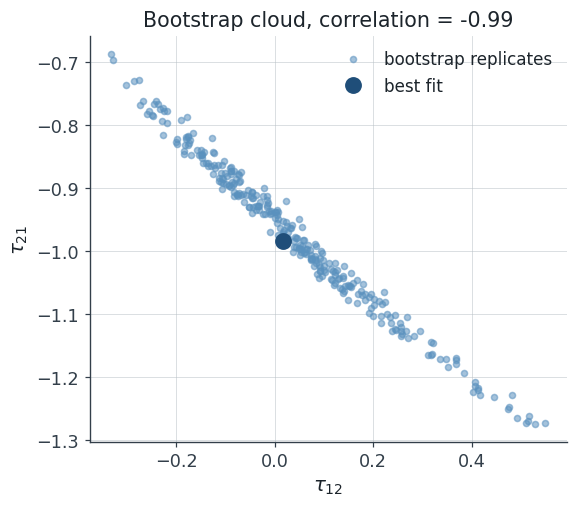

In [23]:
fit = v.fit(d, "nrtl")            # Barker: objective 'P' for isothermal data
print(fit.summary())

boot = v.bootstrap(d, "nrtl", n_boot=300, seed=2)
lo, hi = boot["ci95"]
print()
for i, nm in enumerate(fit.model.param_names):
    print(f"  {nm:<8}{fit.params[i]:+.4f}   linearised +/- {fit.stderr[i]:.4f}"
          f"   bootstrap 95% [{lo[i]:+.4f}, {hi[i]:+.4f}]")
print(f"  parameter correlation {boot['corr'][0, 1]:+.4f}")

pl.bootstrap_plot(boot)
plt.show()

The two NRTL parameters are correlated at $-0.99$. The bootstrap interval on
$\tau_{12}$ runs from $-0.26$ to $+0.47$ — it does not even exclude zero — while
$\tau_{21}$ is pinned near $-0.98$. Quoting
$\tau_{12} = 0.018 \pm 0.191$ and $\tau_{21} = -0.984 \pm 0.132$ as two
independent intervals claims a rectangle in parameter space; the data support a
narrow diagonal sliver inside it. The cloud in the figure is the honest object.

**This is what fitting real data looks like.** On the synthetic set in Module 4
you could check the answer. Here the only checks available are internal: does
the model reproduce $y$ it was not fitted to (rms $\mathrm{d}y = 0.0088$,
against a reported $u(y_1)$ of up to 0.021 — yes, within the measurement), and
does an independent route agree (Section 8 puts these same parameters inside a
cubic equation of state and predicts the pressures again).

**Question 6.1.** The AIC ranking puts two-parameter Margules first and NRTL
1.96 behind it. A $\Delta$AIC below about 2 is conventionally no evidence at
all. Write the shortest honest sentence describing which model these 22 points
support.

**Question 6.2.** Refit with `objective="y"` and `objective="gamma"`
(Module 4 §5). Report how far the parameters move compared with the bootstrap
interval above, and say what that tells you about the phrase "the NRTL
parameters for chloroform + 2-butanone".

---

## 7. Five activity models, one dataset

Module 3 has the feature table. This section does the thing the table cannot:
put all five models on the same real data and look at what actually differs.

Ethanol + water at 101.3 kPa,
[10.1021/je2008704](https://doi.org/10.1021/je2008704), for three reasons. It
has strong positive deviation, so the models are worked hard; it contains no
pure end points, so UNIQUAC is defined everywhere in it; and it is
positive-deviation, so van Laar and Wilson are inside the domain their standard
parameterisations assume.

In [24]:
d = SETS["ethanol-water"]
print(v.model_table(v.compare_models(d)))

--------------------------------------------------------------------------------------------
model         parameters                            rms dP    rms dy       AIC      dAIC
--------------------------------------------------------------------------------------------
UNIQUAC       tau12=+0.6464, tau21=+0.8701               0   0.00420   -134.96      0.00
van Laar      A=+1.7667, B=+0.9211                       0   0.00395   -126.28      8.68
NRTL          tau12=-0.1712, tau21=+1.9330               0   0.00389   -114.77     20.20
Wilson        L12=+0.1754, L21=+0.8597                   0   0.00624    -85.48     49.48
Margules-2    A12=+1.6474, A21=+0.8086                   0   0.00678    -58.46     76.51
Margules-1    A=+1.2560                                  0   0.03112      9.22    144.18
--------------------------------------------------------------------------------------------


UNIQUAC first, van Laar second, NRTL third, and then a real gap down to Wilson
and Margules. But rms $\mathrm{d}y$ for the top three is 0.0042, 0.0040 and
0.0039 against a reported $u(y_1) = 0.015$: **the three best models are
indistinguishable within the measurement error**, and the AIC ordering among
them is being driven by differences smaller than the data can resolve.

So what *does* separate them? Not the fit. Ask instead what each one says about
the limit the data barely reach.

In [25]:
EPS = 1e-9

def ginf(model):
    """(ln gamma_1^inf, ln gamma_2^inf) of a model, from its own algebra."""
    l1, _ = model.ln_gamma(np.array([EPS]))
    _, l2 = model.ln_gamma(np.array([1 - EPS]))
    return float(l1[0]), float(l2[0])

fits = {m: v.fit(d, m) for m in
        ("margules", "vanlaar", "wilson", "nrtl", "uniquac")}
print(f"{'model':12s}{'gamma1_inf':>12}{'gamma2_inf':>12}{'rms dy':>10}")
for k, f in fits.items():
    a, b = ginf(f.model)
    print(f"{k:12s}{np.exp(a):>12.3f}{np.exp(b):>12.3f}{f.rms_y:>10.5f}")
print(f"\nfrom the data by Redlich-Kister extrapolation (Section 1): "
      f"{gamma_infinity(d)[0]:.3f}, {gamma_infinity(d)[1]:.3f}")

model         gamma1_inf  gamma2_inf    rms dy
margules           5.194       2.245   0.00678
vanlaar            5.852       2.512   0.00395
wilson             6.558       2.653   0.00624
nrtl               5.771       2.487   0.00389
uniquac            5.997       2.544   0.00420

from the data by Redlich-Kister extrapolation (Section 1): 5.713, 2.566


$\gamma_1^\infty$ spreads from 5.19 (Margules) to 6.56 (Wilson) — 26 % — on
models that fit the measured range equally well. That is Module 4 §9's point,
made on real data: the models agree where there are measurements and disagree
where there are not.

### 7.1 Pinning the ends, to see the middle

Now remove that difference deliberately. Solve each model's two parameters so
that **every model has exactly the same $\gamma_1^\infty$ and
$\gamma_2^\infty$** — the values NRTL's fit produced. Two equations, two
unknowns, for each model. Whatever is left after that is the shape of $G^E$,
and nothing else.

In [26]:
from scipy.optimize import fsolve

TARGET = ginf(fits["nrtl"].model)
UQ = dict(r1=d.c1.r, q1=d.c1.q, r2=d.c2.r, q2=d.c2.q)

def make(name, p):
    return v.build(name, p, **(UQ if name == "uniquac" else {}))

def pin(name, p0):
    """Parameters that reproduce TARGET exactly, whatever the functional form."""
    def resid(p):
        a, b = ginf(make(name, p))
        return [a - TARGET[0], b - TARGET[1]]
    p = fsolve(resid, p0)
    return make(name, p), np.max(np.abs(resid(p)))

STARTS = {"margules": [1.7, 0.9], "vanlaar": [1.7, 0.9], "wilson": [0.2, 0.9],
          "nrtl": [-0.17, 1.93], "uniquac": [0.65, 0.87]}
pinned = {}
print(f"target: gamma1_inf = {np.exp(TARGET[0]):.4f}, "
      f"gamma2_inf = {np.exp(TARGET[1]):.4f}\n")
print(f"{'model':12s}{'parameters':>26}{'residual':>12}"
      f"{'gE/RT at x1=0.5':>18}")
for k, p0 in STARTS.items():
    mm, res = pin(k, p0)
    pinned[k] = mm
    print(f"{k:12s}{str(np.round(mm.params, 4)):>26}{res:>12.1e}"
          f"{float(mm.gE_RT(0.5)):>18.4f}")

target: gamma1_inf = 5.7709, gamma2_inf = 2.4873

model                       parameters    residual   gE/RT at x1=0.5
margules               [1.7528 0.9112]     0.0e+00            0.3330
vanlaar                [1.7528 0.9112]     0.0e+00            0.2998
wilson                 [0.191  0.9029]     1.0e-13            0.2841
nrtl                 [-0.1712  1.933 ]     3.3e-13            0.3030
uniquac                [0.6509 0.8791]     3.5e-13            0.2956


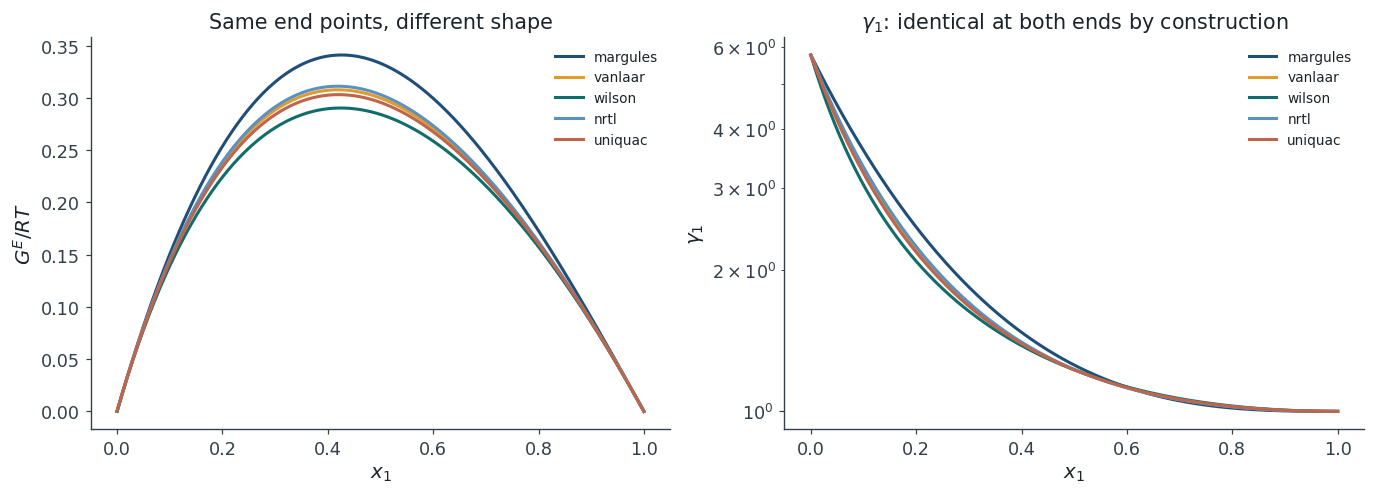

gE/RT at x1 = 0.5 ranges 0.2841 to 0.3330, a spread of 16.1 % of the mean


In [27]:
xs = np.linspace(1e-4, 1 - 1e-4, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for (k, mm), col in zip(pinned.items(), pl.CYCLE):
    axes[0].plot(xs, mm.gE_RT(xs), "-", lw=2.0, color=col, label=k)
    l1, l2 = mm.ln_gamma(xs)
    axes[1].plot(xs, np.exp(l1), "-", lw=2.0, color=col, label=k)
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$G^E/RT$")
axes[0].set_title("Same end points, different shape")
axes[1].set_yscale("log")
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel(r"$\gamma_1$")
axes[1].set_title(r"$\gamma_1$: identical at both ends by construction")
for a in axes:
    a.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

g = np.array([float(mm.gE_RT(0.5)) for mm in pinned.values()])
print(f"gE/RT at x1 = 0.5 ranges {g.min():.4f} to {g.max():.4f}, "
      f"a spread of {100 * (g.max() - g.min()) / g.mean():.1f} % of the mean")

With both infinite-dilution limits forced to agree exactly, $G^E/RT$ at the
equimolar point still ranges from 0.284 (Wilson) to 0.333 (Margules) — a spread
of 16.1 %. **That residue is the functional form and nothing else.** It is what
you are choosing when you choose a model, and it is why two papers can report
"the same" $\gamma^\infty$ for a system and disagree about the middle of the
range.

Note also that Margules and van Laar come out with *identical parameters*
(1.7528, 0.9112). That is not a coincidence: in both models the two parameters
are defined as $\ln\gamma_1^\infty$ and $\ln\gamma_2^\infty$. Same numbers,
different functions, different curves. Parameters carry their functional form
with them, and a parameter value quoted without its model is meaningless.

### 7.2 Wilson cannot split a liquid, and it is not a question of parameters

Module 4 §9 and Module 5 §4 both note this. Here is the algebra.

For Wilson,

$$\frac{G^E}{RT} = -x_1\ln(x_1 + \Lambda_{12}x_2) - x_2\ln(x_2 + \Lambda_{21}x_1)$$

Write $A = x_1 + \Lambda_{12}x_2$ and $B = x_2 + \Lambda_{21}x_1$. Differentiate
$\Delta g_{\rm mix}/RT = x_1\ln x_1 + x_2\ln x_2 + G^E/RT$ twice and the result
collapses to

$$\boxed{\;\frac{\mathrm{d}^2}{\mathrm{d}x_1^2}\frac{\Delta g_{\rm mix}}{RT}
  \;=\; \frac{\Lambda_{12}^2}{x_1 A^2} \;+\; \frac{\Lambda_{21}^2}{x_2 B^2}\;}$$

**A sum of two squares divided by positive quantities.** For any
$\Lambda_{12}, \Lambda_{21} > 0$ — and both must be positive, they are ratios of
Boltzmann factors — this is strictly positive at every composition. A function
whose second derivative is never negative is convex, and a convex
$\Delta g_{\rm mix}$ has no common tangent, hence no phase split. Ever.

This is a theorem about the algebra. No amount of fitting can get round it, and
a paper that reports Wilson parameters for a partially miscible pair has made a
category error. Verify the closed form against a numerical derivative before
believing it.

In [28]:
def d2g_wilson_closed(L12, L21, x1):
    """The boxed expression above."""
    x2 = 1 - x1
    A, B = x1 + L12 * x2, x2 + L21 * x1
    return L12 ** 2 / (x1 * A ** 2) + L21 ** 2 / (x2 * B ** 2)

rng = np.random.default_rng(1)
worst, smallest = 0.0, np.inf
for _ in range(4000):
    L12, L21 = np.exp(rng.uniform(-9, 3, 2))     # 1.2e-4 to 20, both parameters
    x = rng.uniform(0.02, 0.98)
    a = d2g_wilson_closed(L12, L21, x)
    b = float(F.d2g_mix(v.Wilson([L12, L21]), np.array([x]))[0])
    worst = max(worst, abs(a - b) / max(1.0, abs(a)))
    smallest = min(smallest, a)
print(f"4000 random (Lambda12, Lambda21, x1):")
print(f"  max relative difference, closed form vs numerical d2g/dx2: {worst:.1e}")
print(f"  smallest value of d2g/dx2 found anywhere:                  {smallest:.4f}")
print("  never negative, and it cannot be: it is a sum of two positive terms.")

print("\nfor contrast, two-suffix Margules, which is a single quadratic:")
for A in (1.9, 2.0, 2.1, 2.6):
    gap = F.miscibility_gap(v.TwoSuffixMargules([A]))
    print(f"  A = {A}: min d2g/dx2 = "
          f"{float(np.min(F.d2g_mix(v.TwoSuffixMargules([A]), np.linspace(0.01, 0.99, 999)))):+.3f}"
          + (f", binodal {gap['x1_phase_a']:.4f} / {gap['x1_phase_b']:.4f}"
             if gap else ", no split"))

4000 random (Lambda12, Lambda21, x1):
  max relative difference, closed form vs numerical d2g/dx2: 4.5e-06
  smallest value of d2g/dx2 found anywhere:                  0.0000
  never negative, and it cannot be: it is a sum of two positive terms.

for contrast, two-suffix Margules, which is a single quadratic:


  A = 1.9: min d2g/dx2 = +0.200, no split
  A = 2.0: min d2g/dx2 = +0.000, no split
  A = 2.1: min d2g/dx2 = -0.200, binodal 0.3146 / 0.6854
  A = 2.6: min d2g/dx2 = -1.200, binodal 0.1240 / 0.8760


The closed form matches a numerical second derivative to one part in $10^5$
over four thousand random parameter sets and compositions, and its smallest
value anywhere is 0. (It approaches zero only as $\Lambda \to 0$, the
degenerate limit in which the model stops describing a mixture at all.) Margules
crosses at $A = 2$ exactly and splits above it, because a quadratic $G^E$ can
overcome the ideal entropy and the Wilson form cannot.

**Question 7.1.** Wilson still fits ethanol + water — badly, but it fits, at
$\Delta$AIC 49. Look at what its fitted $\gamma_1^\infty$ has to become (the
table in §7). Explain why that number is a symptom of the constraint above
rather than a result.

**Question 7.2.** Section 7.1 pinned five models to the same two end values. If
you instead pinned them to the same $G^E$ at $x_1 = 0.5$ and the same
$\gamma_1^\infty$, which single quantity would you predict disagrees most, and
where?

---

## 8. $\gamma$–$\varphi$, $\varphi$–$\varphi$, and the bridge between them

Two routes to the same equilibrium.

**$\gamma$–$\varphi$.** The liquid gets an activity model, the vapour gets an
equation of state (or nothing), and they meet at
$x_i\gamma_i f_i^{\circ} = y_i\hat\varphi_i P$. It needs a pure-component
vapour pressure for every species, so it cannot be used above a critical
temperature, and the two phases are described by different mathematics.

**$\varphi$–$\varphi$.** One equation of state for both phases,
$x_i\hat\varphi_i^L = y_i\hat\varphi_i^V$. Continuous through the critical
point, no vapour pressure needed — and, with the classical van der Waals
one-fluid mixing rule, incapable of bending $a(x)$ into the shape a
hydrogen-bonding mixture needs.

The two mixing rules in `vlekit.gemix` are the bridge: they *require* the
equation of state to reproduce a chosen $G^E$ at infinite pressure. Read the
derivation at the top of `vlekit/gemix.py`; it is done there rather than
asserted.

**Assumptions in everything below**, stated once: Peng–Robinson with the 1976
$\alpha$ function; critical constants and $\omega$ from
`vlekit.data.LIBRARY`; classical $k_{ij} = 0$ unless said otherwise; the
activity model is the NRTL fitted in Section 6, by Barker's method, with an
ideal vapour. The reference state for $\gamma$ is the pure liquid at the system
$T$ and $P$.

In [29]:
d = SETS["chloroform-butanone"]
T = 303.15
gE = v.fit(d, "nrtl").model            # the Section 6 fit, unchanged
print(f"NRTL from Section 6: tau12 = {gE.params[0]:+.4f}, "
      f"tau21 = {gE.params[1]:+.4f}, gE/RT at x1=0.5 = {gE.gE_RT(0.5):+.4f}")

pr = CU.PengRobinson([d.c1, d.c2])
print("\nthe floor nobody can get under: pure vapour pressures at 303.15 K")
print(f"{'':14s}{'measured':>10}{'Antoine':>10}{'PR EoS':>10}{'PR error':>10}")
for i, (c, Pm) in enumerate(((d.c1, d.P[-1]), (d.c2, d.P[0]))):
    Pe = CU.psat(pr, i, T)
    print(f"{c.name:14s}{Pm:>10.2f}{float(c.Psat(T)):>10.3f}{Pe:>10.3f}"
          f"{100 * (Pe - Pm) / Pm:>9.2f}%")

NRTL from Section 6: tau12 = +0.0178, tau21 = -0.9841, gE/RT at x1=0.5 = -0.2777

the floor nobody can get under: pure vapour pressures at 303.15 K
                measured   Antoine    PR EoS  PR error
chloroform         32.19    32.330    32.125    -0.20%
2-butanone         15.74    15.224    15.197    -3.45%


Peng–Robinson gets the pure vapour pressures from $T_c$, $P_c$ and $\omega$
alone, and misses 2-butanone by $-3.5$ %. **No mixing rule can repair that**, so
a couple of per cent in the mixture pressures is the floor for every
$\varphi$–$\varphi$ row below, not a failure. The $\gamma$–$\varphi$ route uses
Antoine correlations fitted to the pure components directly and does not carry
this error at all — which is a real advantage of that route and is usually left
unsaid.

In [30]:
def X(x1):
    return np.array([x1, 1 - x1])

def eos_deviations(mix):
    """Bubble pressure and vapour composition at every measured x1, from the EoS.

    `gemix.bubble_P` forces the liquid root for x and the vapour root for y and
    iterates on K. `cubic.bubble_P` (Newton, root selected by Gibbs energy) is
    the better routine near a critical point and fails from a cold start here;
    the docstring in gemix.py explains why.
    """
    dP, dy = [], []
    for x1, Pm, ym in zip(d.x1, d.P, d.y1):
        P0 = (GX.gamma_phi_start(mix, X(x1), T)[0]
              if isinstance(mix, GX.GEMixingRule) else Pm)
        P, y, it = GX.bubble_P(mix, X(x1), T, P0=P0)
        dP.append(np.nan if it < 0 else 100 * (P - Pm) / Pm)
        dy.append(np.nan if it < 0 else y[0] - ym)
    return np.array(dP), np.array(dy)

rows = []
Pg, yg = v.bubble_P(gE, d.x1, d.T, d.c1, d.c2, vapour="virial")
rows.append(("gamma-phi: NRTL + Antoine + virial",
             100 * (Pg - d.P) / d.P, yg - d.y1))
for name, mix in (
        ("phi-phi: classical PR, k12 = 0", CU.PengRobinson([d.c1, d.c2])),
        ("phi-phi: Huron-Vidal + NRTL", GX.HuronVidal([d.c1, d.c2], gE)),
        ("phi-phi: Wong-Sandler, k12 = 0",
         GX.WongSandler([d.c1, d.c2], gE, kij=0.0)),
        ("phi-phi: Wong-Sandler, k12 = -0.1",
         GX.WongSandler([d.c1, d.c2], gE, kij=-0.1))):
    a, b = eos_deviations(mix)
    rows.append((name, a, b))

print(f"{'route':36s}{'AAD P %':>9}{'max |dP| %':>12}{'rms dy':>9}")
for name, a, b in rows:
    print(f"{name:36s}{np.nanmean(np.abs(a)):>9.2f}{np.nanmax(np.abs(a)):>12.2f}"
          f"{np.sqrt(np.nanmean(b ** 2)):>9.4f}")

route                                 AAD P %  max |dP| %   rms dy
gamma-phi: NRTL + Antoine + virial       1.23        3.53   0.0085
phi-phi: classical PR, k12 = 0          21.94       37.91   0.0728
phi-phi: Huron-Vidal + NRTL              2.08        3.45   0.0132
phi-phi: Wong-Sandler, k12 = 0           3.97        7.24   0.0199
phi-phi: Wong-Sandler, k12 = -0.1        1.47        3.46   0.0107


The classical rule with $k_{12} = 0$ is out by 22 % on average and 38 % at
worst. Putting the *same* NRTL model inside the same equation of state through
Huron–Vidal brings that to 2.1 %, a factor of ten, with **no parameter fitted
to the mixture's pressures at all** — the NRTL parameters came from Section 6,
which never saw the equation of state.

But now do the comparison properly. Huron–Vidal carries two adjustable numbers
(the NRTL $\tau$s) and the classical rule at $k_{12}=0$ carries none. Give the
classical rule its one parameter:

In [31]:
from scipy.optimize import minimize_scalar

def classical_aad(k):
    mix = CU.PengRobinson([d.c1, d.c2], kij=np.array([[0.0, k], [k, 0.0]]))
    return np.nanmean(np.abs(eos_deviations(mix)[0]))

r = minimize_scalar(classical_aad, bounds=(-0.5, 0.3), method="bounded",
                    options={"xatol": 1e-4})
best = CU.PengRobinson([d.c1, d.c2], kij=np.array([[0.0, r.x], [r.x, 0.0]]))
a, b = eos_deviations(best)
print(f"classical PR with k12 fitted to these data: k12 = {r.x:+.4f}")
print(f"   AAD P {np.nanmean(np.abs(a)):.2f} %   rms dy {np.sqrt(np.nanmean(b ** 2)):.4f}")
print(f"   (Huron-Vidal, for comparison: 2.08 % and 0.0132)")

classical PR with k12 fitted to these data: k12 = -0.0721
   AAD P 1.34 %   rms dy 0.0087
   (Huron-Vidal, for comparison: 2.08 % and 0.0132)


**The classical rule with one fitted $k_{12}$ beats Huron–Vidal on this
dataset.** 1.34 % against 2.08 %. That is not the result the usual telling of
this story leads you to expect, and it should be stated plainly rather than
buried.

It is also not surprising once you look at what was actually compared. The
fitted $k_{12}$ was regressed against *these very pressures*; the Huron–Vidal
parameters were regressed against the same pressures through a different model
and then handed to the equation of state without adjustment. And chloroform +
2-butanone is only moderately non-ideal, $G^E/RT = -0.28$ at the equimolar
point — well inside what a single $k_{12}$ can absorb.

The case for the $G^E$ route is therefore not "it fits better here". It is:

1. it fits comparably here **without being fitted here**, and
2. it does not fall apart where the classical rule does — strongly associating
   mixtures, and extrapolation in temperature.

The second claim is the one the next subsection makes testable.

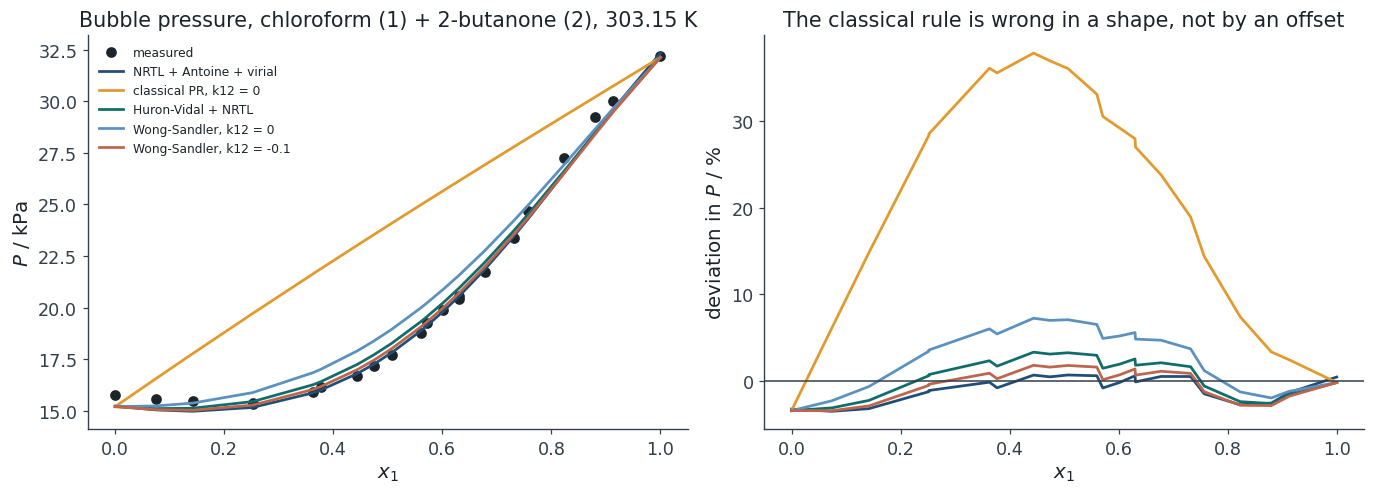

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
axes[0].plot(d.x1, d.P, "o", color=pl.INK, ms=6, label="measured")
for (name, a, b), col in zip(rows, pl.CYCLE):
    axes[0].plot(d.x1, d.P * (1 + a / 100), "-", lw=1.8, color=col,
                 label=name.split(": ")[-1])
    axes[1].plot(d.x1, a, "-", lw=1.8, color=col)
axes[1].axhline(0, color=pl.GRAPHITE, lw=1.0)
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$P$ / kPa")
axes[0].set_title("Bubble pressure, chloroform (1) + 2-butanone (2), 303.15 K")
axes[0].legend(loc="best", fontsize=8)
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("deviation in $P$ / %")
axes[1].set_title("The classical rule is wrong in a shape, not by an offset")
plt.tight_layout(); plt.show()

### 8.1 The second virial coefficient: why Wong–Sandler exists

Expand any cubic at low density:

$$Z = 1 + \frac{B(T,x)}{v} + \dots, \qquad B(T,x) = b(x) - \frac{a(T,x)}{RT}$$

Statistical mechanics says $B$ for a mixture is **exactly quadratic** in
composition. It is a sum over pairs of molecules, and there is nothing else it
could be:

$$B(T, x) = \sum_i\sum_j x_i x_j B_{ij}$$

The classical rule satisfies this by accident of its own form ($a$ quadratic,
$b$ linear). **Huron–Vidal does not**: it keeps $b$ linear and sets
$a/b = \sum x_i a_i/b_i + G^E/C$, so $B = b(1 - D)$ inherits the composition
dependence of $G^E$, which for any real activity model is not a quadratic.
Wong–Sandler imposes the quadratic form as a second equation and solves for $a$
and $b$ together, which is why its $b_{\rm mix}$ is not linear.

Measure the violation. The reference quadratic is built to agree with each rule
at $x_1 = 0$, $\tfrac12$ and $1$ by construction, so what is left is genuinely
non-quadratic content and not a bad choice of $B_{12}$. Two denominators are
reported: $B$ itself, which is dominated by the pure components and makes the
error look tiny, and the **excess** second virial
$B - \sum_i x_i B_i$, which is the part mixing is responsible for and is the
honest one.

In [33]:
def virial_violation(mix, T):
    B11 = GX.second_virial(mix, T, mix.unit(0))
    B22 = GX.second_virial(mix, T, mix.unit(1))
    worst = frac = 0.0
    for x1 in np.linspace(0.02, 0.98, 49):
        x = X(x1)
        B = GX.second_virial(mix, T, x)
        Bq = GX.second_virial_quadratic(mix, T, x)
        excess = B - (x1 * B11 + (1 - x1) * B22)
        worst = max(worst, abs(B - Bq))
        if abs(excess) > 1e-9:
            frac = max(frac, abs(B - Bq) / abs(excess))
    return worst, frac

hv = GX.HuronVidal([d.c1, d.c2], gE)
ws = GX.WongSandler([d.c1, d.c2], gE, kij=0.0)
Bh = GX.second_virial(hv, T, X(0.5))
print(f"chloroform + 2-butanone at {T} K,  B(x1=0.5) = {Bh * 1e6:.1f} cm3/mol")
for nm, mix in (("Huron-Vidal", hv), ("Wong-Sandler", ws)):
    w, f = virial_violation(mix, T)
    print(f"  {nm:14s} max |B - B_quadratic| = {w * 1e6:10.4f} cm3/mol"
          f"  ({w:8.1e} m3/mol)   = {100 * f:6.3f} % of the excess")
print("\nWong-Sandler's number is machine epsilon. It is an identity for that")
print("rule -- b_mix(1 - D) = Q, and Q is a quadratic form by construction.")

chloroform + 2-butanone at 303.15 K,  B(x1=0.5) = -1038.9 cm3/mol
  Huron-Vidal    max |B - B_quadratic| =     0.2410 cm3/mol  ( 2.4e-07 m3/mol)   =  2.198 % of the excess
  Wong-Sandler   max |B - B_quadratic| =     0.0000 cm3/mol  ( 4.3e-19 m3/mol)   =  0.000 % of the excess

Wong-Sandler's number is machine epsilon. It is an identity for that
rule -- b_mix(1 - D) = Q, and Q is a quadratic form by construction.


In [34]:
# and the violation grows with the strength of G^E, which is the reason
# Huron-Vidal parameters do not travel in temperature
ew = SETS["ethanol-water"]
gE_ew = v.fit(ew, "nrtl").model
Tw = float(np.mean(ew.T))
_, f_weak = virial_violation(hv, T)
_, f_strong = virial_violation(GX.HuronVidal([ew.c1, ew.c2], gE_ew), Tw)
print("non-quadratic content of the excess second virial, Huron-Vidal:")
print(f"  chloroform + 2-butanone  (gE/RT = {gE.gE_RT(0.5):+.3f} at x=1/2): "
      f"{100 * f_weak:.2f} %")
print(f"  ethanol + water          (gE/RT = {gE_ew.gE_RT(0.5):+.3f} at x=1/2): "
      f"{100 * f_strong:.2f} %")
print(f"  ratio: {f_strong / f_weak:.1f}x")

non-quadratic content of the excess second virial, Huron-Vidal:
  chloroform + 2-butanone  (gE/RT = -0.278 at x=1/2): 2.20 %
  ethanol + water          (gE/RT = +0.303 at x=1/2): 22.85 %
  ratio: 10.4x


Wong–Sandler reproduces the quadratic composition dependence to
$4\times10^{-19}$ m³/mol — machine precision against a $B$ of
$-1.04\times10^{-3}$ m³/mol, so sixteen significant figures, because for that
rule it is an identity rather than an approximation. Huron–Vidal misses it by
0.24 cm³/mol, which is 2.2 % of the excess
second virial for this moderately non-ideal system and **22.9 % for ethanol +
water**, a factor of ten worse for a $G^E$ of comparable magnitude but opposite
sign and much greater skew.

That is the whole argument for Wong–Sandler, and it is an argument about a
region nobody measured. The error Huron–Vidal makes is an error in the
**low-density limit** — where a cubic ought to be exact, because the virial
expansion is exact there — and it is proportional to $G^E$. A rule that is wrong
in a limit it need not be wrong in will drift when you move away from the
conditions it was fitted at, which is the practical form of the complaint that
Huron–Vidal parameters do not extrapolate in temperature.

Notice what the two subsections together say. On the data in front of us,
Wong–Sandler with $k_{12} = 0$ is the *worst* of the three $G^E$ routes at
3.97 %; give it its one binary parameter, $k_{12} = -0.1$, and at 1.47 % it
becomes the best of the three (though still not better than a classical
$k_{12}$ fitted to the same pressures). Its advantage is not accuracy at the
fitted condition. It is that it buys that accuracy without giving up an exact
result.

### 8.2 The trap in testing Wong–Sandler

One more thing, because it costs three lines and it catches people.

The infinite-pressure derivation matches an excess **Helmholtz** energy, not a
Gibbs energy. $G^E$ and $A^E$ differ by $PV^E$. Huron–Vidal keeps $b$ linear, so
its excess volume at infinite pressure is zero and the two coincide.
Wong–Sandler's $b_{\rm mix}$ is not linear, so its $G^E$ from the equation of
state **diverges** like $PV^E$ while its $A^E$ converges.

Test Wong–Sandler the way Huron–Vidal is tested and it looks broken. It is not.

In [35]:
target = gE.gE_RT(0.4)
print(f"activity model at x1 = 0.4:  G^E/RT = {target:.8f}\n")
print(f"{'P / kPa':>10}{'HV: G^E/RT':>14}{'WS: G^E/RT':>16}{'WS: A^E/RT':>14}")
for Pinf in (1e7, 1e9, 1e11):
    print(f"{Pinf:>10.0e}{GX.gE_from_eos(hv, T, Pinf, X(0.4)):>14.8f}"
          f"{GX.gE_from_eos(ws, T, Pinf, X(0.4)):>16.1f}"
          f"{GX.aE_from_eos(ws, T, Pinf, X(0.4)):>14.8f}")
print("\nHuron-Vidal's G^E converges to the activity model. Wong-Sandler's")
print("G^E grows linearly in P (it is P V^E); its A^E is what converges.")

activity model at x1 = 0.4:  G^E/RT = -0.25883629

   P / kPa    HV: G^E/RT      WS: G^E/RT    WS: A^E/RT
     1e+07   -0.25846474            -9.6   -0.25650030
     1e+09   -0.25883252          -937.4   -0.25881200
     1e+11   -0.25883625        -93713.0   -0.25883605

Huron-Vidal's G^E converges to the activity model. Wong-Sandler's
G^E grows linearly in P (it is P V^E); its A^E is what converges.


**Question 8.1.** The classical rule with a fitted $k_{12}$ matched Huron–Vidal
here. Design the experiment that would separate them, given that you may
measure the same binary at one more temperature. What would you predict, and
what result would make you abandon the $G^E$ route?

**Question 8.2.** Wong–Sandler's $k_{12} = -0.1$ improved the fit. That
$k_{12}$ multiplies the whole second-virial cross coefficient; the classical
$k_{12}$ multiplies $\sqrt{a_ia_j}$ alone. The best classical value here was
$-0.072$. Explain why substituting one for the other is a mistake, and what
would happen if you did.

**Question 8.3.** Both rules were derived at infinite pressure and used at
20 kPa. What survives the extrapolation, and what does not? (The tables in this
section contain the evidence for both halves of your answer.)

---

## Exercises

**E1. The fifth type.** The course numbering stops at 4. Construct — from a
model, not from data — a binary that has $G^E > 0$ over part of the range and
$G^E < 0$ over the rest, and say what its $P$–$x$ curve looks like. Then search
the literature for a real system that does this and report whether you found
one.

**E2. Your own paper, classified.** Take the dataset from your Module 4
assignment. Run §1 on it: extrapolate $\gamma^\infty$, compute the
vapour-pressure ratio, predict the type, then check against the measured
relative volatility. If the two disagree, find out which is wrong before doing
anything else.

**E3. The pressure swing, costed.** For ethanol + water, compute the azeotropic
composition at 101.3 kPa and at 15 kPa from the fitted NRTL, and state the
maximum ethanol purity a two-column pressure-swing sequence could reach. Then
state the two assumptions in §2.3 that your answer depends on, and what
measurement would remove each one.

**E4. Consistency signatures.** Take chloroform + 2-butanone and corrupt it
three ways: a constant $+0.01$ offset in $y_1$; a $-0.5$ K error in $T$; the
Antoine constants for 2-pentanone in place of 2-butanone. Run all five tests
each time and tabulate which fail. That table — the *signature* of each fault —
is the useful output of consistency testing, and Module 4 E3 asks for the same
thing on synthetic data where you know the fault.

**E5. Both routes, one system.** Take acetone + chloroform (open access:
[10.3390/app8091519](https://doi.org/10.3390/app8091519)). Fit NRTL, predict
the bubble temperatures by $\gamma$–$\varphi$, then by Huron–Vidal inside
Peng–Robinson. Report both against the measured 101.3 kPa, and explain any
difference in terms of the pure-component vapour pressures each route uses.

**E6. Wilson, disproved by hand.** Reproduce the boxed second-derivative result
in §7.2 with pen and paper. Then state precisely what would have to be true of
$\Lambda_{12}$ and $\Lambda_{21}$ for the result to fail, and why that cannot
happen for a model derived from local compositions.

---

## AI verification exercise

Ask a language model, giving it nothing but these four numbers:

> *"A binary mixture has $\gamma_1^\infty = 2.28$ and $\gamma_2^\infty = 1.36$.
> At the relevant temperatures $P_1^{\rm sat}/P_2^{\rm sat}$ is between 3.6 and
> 4.3. Does this system form an azeotrope?"*

Then ask again with $\gamma_1^\infty = 5.71$, $\gamma_2^\infty = 2.57$ and a
ratio of 2.26.

Those are methanol + water and ethanol + water, and the answers are *no* and
*yes*. But the question as posed names no chemicals, so a model that answers by
recall has nothing to recall — it must do the calculation in §1.1, which is two
multiplications and a comparison.

Record: what each answer was; whether the model produced the condition
$\gamma_1^\infty P_1^{\rm sat}/P_2^{\rm sat}$ versus 1 or merely produced a
verdict; and whether it noticed that the second case straddles 1 while the first
does not. Then name the chemicals and ask again. **If the answer changes when
you name them, the model was not calculating**, and you have found the failure
mode this exercise is for.

A harder version, for which recall is no help at all: ask for the pressure at
which the ethanol + water azeotrope disappears. §2.3 of this notebook says about
7 kPa from a temperature-independent NRTL fit; published estimates say 9–11 kPa;
the honest answer requires stating which model and which data. Any answer given
as a bare number, without that qualification, is a guess dressed as a fact —
whoever produced it.

---

*vlekit and this notebook: Soorathep Kheawhom, 2105603, Chulalongkorn
University.*